In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de


In [1]:

# make grid cell rate maps

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from grid_cells import generate_grid_cells

g = generate_grid_cells(shift=False, rotate=False, num_modules=6, num_neurons_per_mod=100)

print(g.shape)

np.save("GCmaps/GCmaps.npy", g)



[0.         1.04719755 0.78539816 1.57079633 0.52359878 3.76991118]


100%|██████████| 6/6 [00:00<00:00, 82.92it/s]

(44, 44, 100, 6)


In [2]:
# THIS IS NOT REALLY NEEDED HERE, MAPPING ONLY REQUIRES THE PIN, SEE NEXT CELL

# The VNA is only used for reasoning simulations. See script UCM_reasoning.ipynb

# set up vector navigation network (VNA)
# given points A and B in form of grid cell population vector this computes distance 
# similar to distance cell model in Bicanski & Burgess 2019, Current Biology, 
# original model from Bush et al. 2015, Neuron.
# any other neural implementation of a VNA can be substituted 
# here two neural implementetation and a heuristic are available. 

# generates weight file DCab2d, for going from points a & b to the vector d

from vna import generate_vna

generate_vna()


In [3]:
# set up positional inference network (PIN)
# for non-local jumps on the grid sheet
# d can be thought of more generally as an "action" on the grid sheet
# these weights are different from local attractor transition weights

# generates weight file DCad2b, for going from point a and the vector d to point b

from pin import generate_pin

generate_pin()


100%|██████████| 44/44 [00:02<00:00, 21.38it/s]


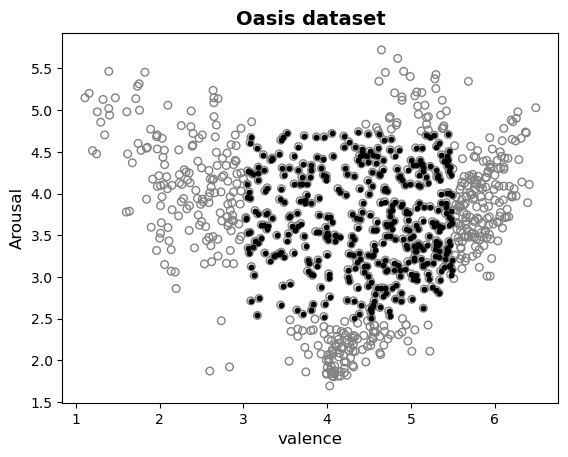

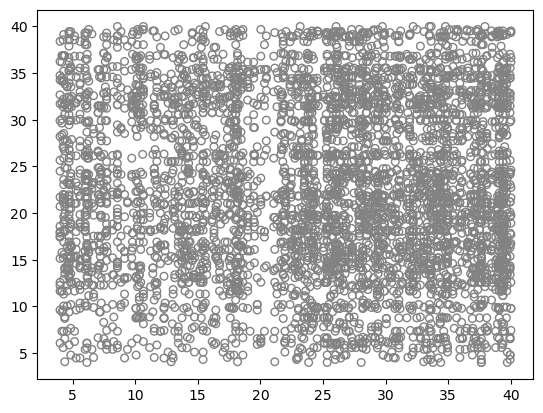

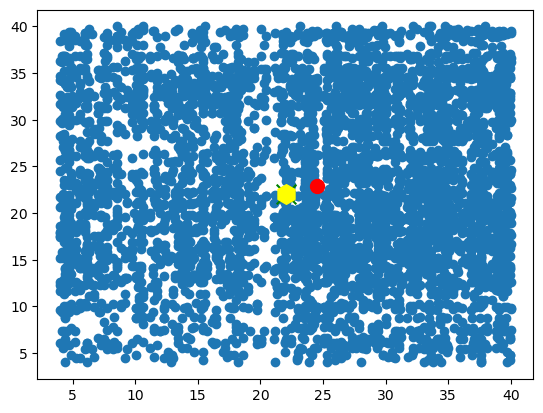

In [ ]:

# load OASIS dataset and rescale

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from helper_fcts import check_dataset_range
from helper_fcts import load_GCs

from prep_datasets import prep_oasis
from prep_datasets import make_oasis_synthetic
from prep_datasets import get_distances

# grid cells
GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

data0 = pd.read_csv("datasets/oasis/ExpData/OASIS.csv", sep=None, engine="python")
IDs  = data0.iloc[:, 0].to_numpy()

data, val, aro = prep_oasis(data0,4,res)

synth = 0
# synthetic data
if synth == 1:
    rng = np.random.default_rng()
    N_new = 5000
    x_new = rng.choice(val, size=N_new, replace=True)
    y_new = rng.choice(aro, size=N_new, replace=True)
    surrogate = np.column_stack([x_new, y_new])
    data = surrogate
    val = data[:,0]
    aro = data[:,1]

eucl_data_dist, v_dist, a_dist = get_distances(data,val,aro)

# check distribution
plt.scatter(val, aro, s=30, facecolors='none', edgecolors=(130/255, 130/255, 130/255))
plt.show()

# now check exact range, though for dataset 1 this is techincally redundant
# in reality startpoint is arbitrary because of periodic torodial grid cell manifold, 
# but our rate maps (as an approximation) are not, so start in the middle
# no loss of generality here.
dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data, dim1=val, dim2=aro, mapsize=res)

# data is now rescaled, this encapsulates the scaling of the grid relative to external space

center = np.mean(data, axis=0)
plt.scatter(data[:,0], data[:,1])
plt.scatter(center[0], center[1], color='red', s=100)
plt.scatter(data[S1ind,0], data[S1ind,1], color='green', s=200, marker='x')
plt.scatter(S1coords[0], S1coords[1], color='yellow', s=200, marker='h')
plt.show()

In [7]:
### map oasis dataset

from pin import pin
from helper_fcts import valid_anchor_indices
from helper_fcts import find_anchors_and_target

### S1 is startpoint we'll anchor to 22,22 on the rate maps, for map size 44
# initial placement purely for simulation convenience

# place first stimulus and prep for rest
startPV     = GCs[22,22,:]
PVs         = np.zeros([N_pts, N_GCs])
PVs_xy      = np.zeros([N_pts,2]) # for map access, reading PVs - is model's belief 
PVs_xy_data = np.zeros([N_pts,2]) # ground truth - is data space, like an experimenter that bins data

# first array: number of stimuli (implicit ID) and population vector (PV)
# second array: indices on rate maps
# need both so we can later visualize

PVs_xy[S1ind,0] = 22
PVs_xy[S1ind,1] = 22

PVs[S1ind,:] = startPV

Stims = np.zeros([N_pts,2])
# first dim: number of stimuli, implicit ID
# second dim: placed yes/no, how often placed, how often used as anchor 

Stims[S1ind,0] = 10000 + S1ind 
Stims[S1ind,1] += 1

### place second stimulus

# pick S2 randomly with a minimum distance
S1v = val[S1ind]
S1a = aro[S1ind]

x_offset = PVs_xy[S1ind,0]-S1v
y_offset = PVs_xy[S1ind,1]-S1a 

PVs_xy_data[S1ind,:] = [val[S1ind]+x_offset,aro[S1ind]+y_offset]

S2ind = np.random.randint(0, N_pts-1)  # first guess, checks pending

# key differene to vision a la Bicanski & Burgess 2019: 
# points on the image where always 
# integer coordinates. here dv,da are almost always floats, though 
# we did rescale the data to use the entire rate maps. But we do not
# need to round a-distance and v-distancesc because DsimVec_X and 
# DsimVec_Y are rounded below.

dist_S1_S2 = eucl_data_dist[S1ind,S2ind]
vect       = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]

# allow for some minimum distance
# Also, S2ind chosen randomly above, make sure it isn't anchored already 

tolerance = 2

while dist_S1_S2 < tolerance:
    S2ind = np.random.randint(0, N_pts-1)
    vect = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
    dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

PVs_xy_data[S2ind,:] = [val[S2ind]+x_offset,aro[S2ind]+y_offset]

# now we have a candidate data point for S2, let's infer the grid cell PV
# this code is verbatim the same as in the visual example

wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW   = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW   = wts_mod["DCxm_2_tGCs_WTS"]
DCypW   = wts_mod["DCyp_2_tGCs_WTS"]
DCymW   = wts_mod["DCym_2_tGCs_WTS"]

vect_S1_S2 = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

xy_tmp = pin(
    DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
    res=res, vect=vect_S1_S2, xc=22, yc=22, GCs=GCs)

nextPV       = GCs[xy_tmp[1],xy_tmp[0],:]
PVs[S2ind,:] = nextPV
PVs_xy[S2ind,0] = xy_tmp[0]
PVs_xy[S2ind,1] = xy_tmp[1]
Stims[S2ind,0] = 10000 + S2ind 
Stims[S2ind,1] += 1

### TRIANGULATION LOOP ###

# triangulate rest among the N_pts in stimulus set
# enforce a minimum distance

N = 1  # for later use, see noise script

T_cntr   = 0 

# first while should terminate fine as we can always find 
# anchors such that the last targets are suffiently far, 
# and thus the Stims array is eventually filled up

while np.any(Stims[:,0] == 0):

    anchors = valid_anchor_indices(Stims, PVs_xy)
    if anchors.size < 2:
        break

    (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
        ) = find_anchors_and_target(Stims, eucl_data_dist, tolerance, v_dist, a_dist, PVs_xy)

    if A1ind is None or np.isnan(STind):
        break
    
    A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors
    A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
    A2xc = int(PVs_xy[A2ind,0])
    A2yc = int(PVs_xy[A2ind,1])

    if not np.isnan(STind):

        # pin does the heavy lifting here. Without noise, this simulation essentially tests the pin

        xy_tmp1 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
            res=res, vect=vect_A1_T, xc=A1xc, yc=A1yc, GCs=GCs)

        xy_tmp2 = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
            res=res, vect=vect_A2_T, xc=A2xc, yc=A2yc, GCs=GCs)

        # pin returns [nan, nan] when it can't find a close enough match
        if np.any(np.isnan(xy_tmp1)) or np.any(np.isnan(xy_tmp2)):
        # skip this target, try a different anchor/target combo next iteration
            continue

    else: 
        break # no more target to be assigned

    # now check for overlap
    if (abs(xy_tmp1[0]-xy_tmp2[0])<=tolerance) and (abs(xy_tmp1[1]-xy_tmp2[1])<=tolerance):
        coords = [round(np.mean([xy_tmp1[0], xy_tmp2[0]])), round(np.mean([xy_tmp1[1], xy_tmp2[1]]))]
    else:
        coords = xy_tmp1 

    #print(coords)

    # now track result
    PVs[STind,:]         = GCs[coords[1],coords[0],:]
    PVs_xy[STind,0]      = coords[0] # internal to the system memory
    PVs_xy[STind,1]      = coords[1]
    Stims[STind,0]       = 10000 + STind # to avoid STind = 0 being an index and condition
    Stims[STind,1]       = Stims[STind,1] + 1
    PVs_xy_data[STind,:] = [val[STind]+x_offset,aro[STind]+y_offset] # for reconstruction

    T_cntr = T_cntr+1
    
    
    
print('counter', T_cntr)
print('Stims shape', Stims.shape)

if synth == 0:
    configname = 'BaseModel_Noise0'
else:
    configname = 'BaseModel_Noise0_SYNTH'

filename1 = f"datasets/oasis/{configname}_anchored_stimuli.npy"
np.save(filename1, Stims)

filename2 = f"datasets/oasis/{configname}_PVs.npy"
np.save(filename2, PVs)

filename3 = f"datasets/oasis/{configname}_PVcoordinates.npy"
np.save(filename3, PVs_xy)

filename33 = f"datasets/oasis/{configname}_PVcoordinates_data.npy"
np.save(filename33, PVs_xy_data)

filename4 = f"datasets/oasis/{configname}_rescaled_data.npy"
np.save(filename4, data)

if synth == 0:
    filename44 = f"datasets/oasis/OASIS_data_rescaled.npy"
else:
    filename44 = f"datasets/oasis/OASIS_data_rescaled_synth.npy"   
np.save(filename44, data)

filename5 = f"datasets/oasis/{configname}_center.npy"
np.save(filename5, S1ind)

# filename6 = f"datasets/oasis/{configname}_xoff.npy"
# np.save(filename6, x_offset)

# filename7 = f"datasets/oasis/{configname}_yoff.npy"
# np.save(filename7, y_offset)

print('##### Done! #####')

counter 4998
Stims shape (5000, 2)
##### Done! #####


##### [2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]


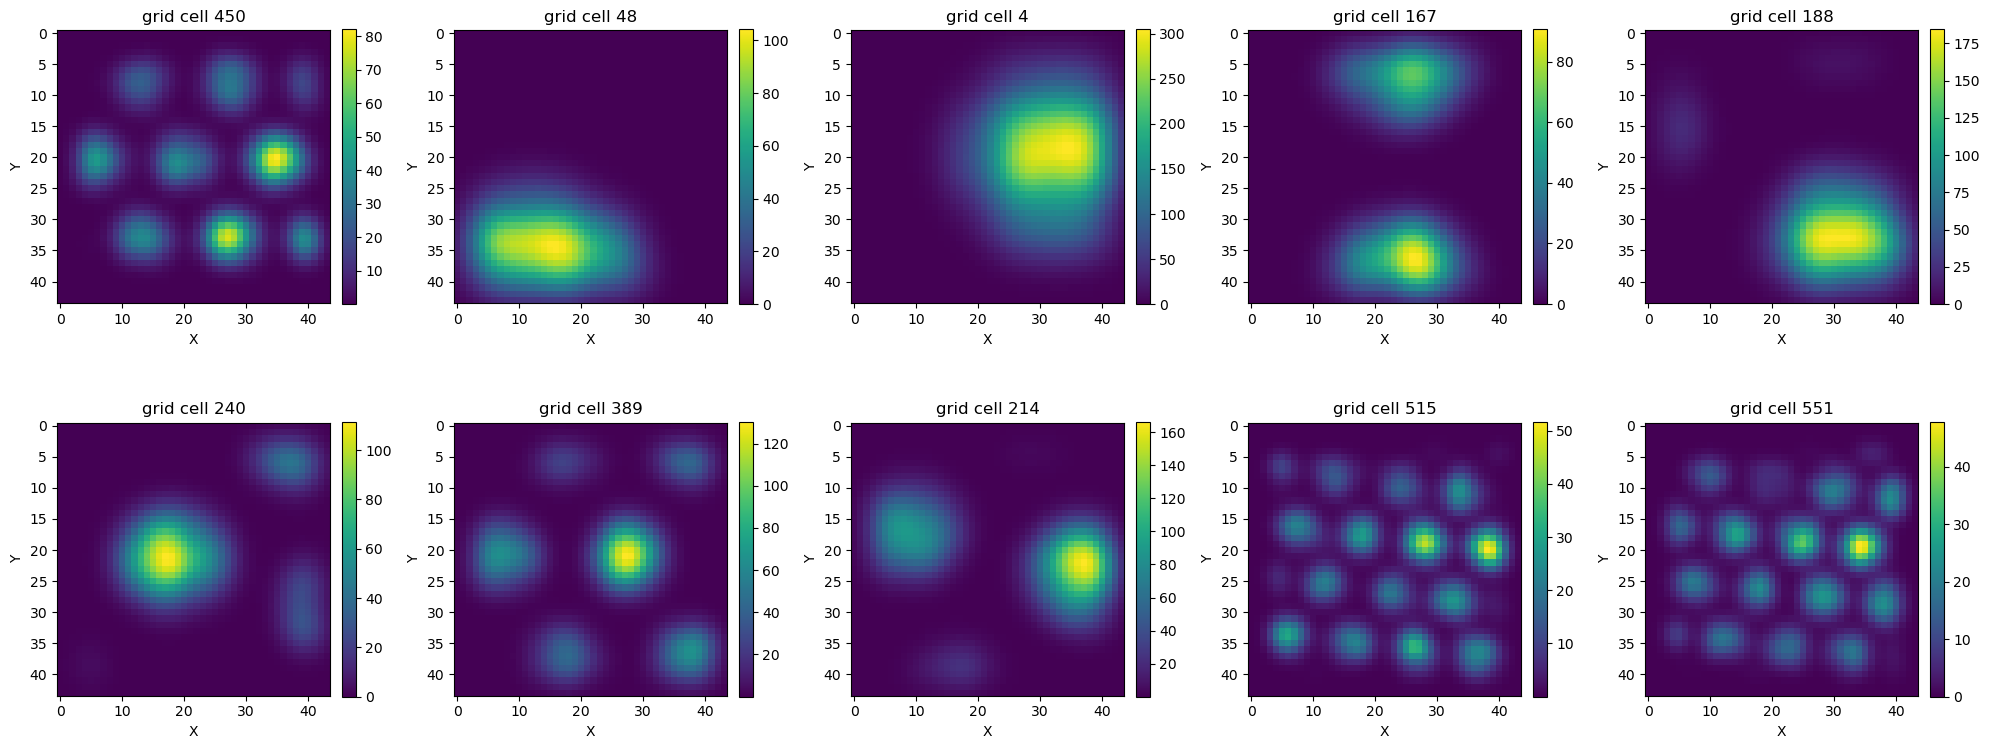

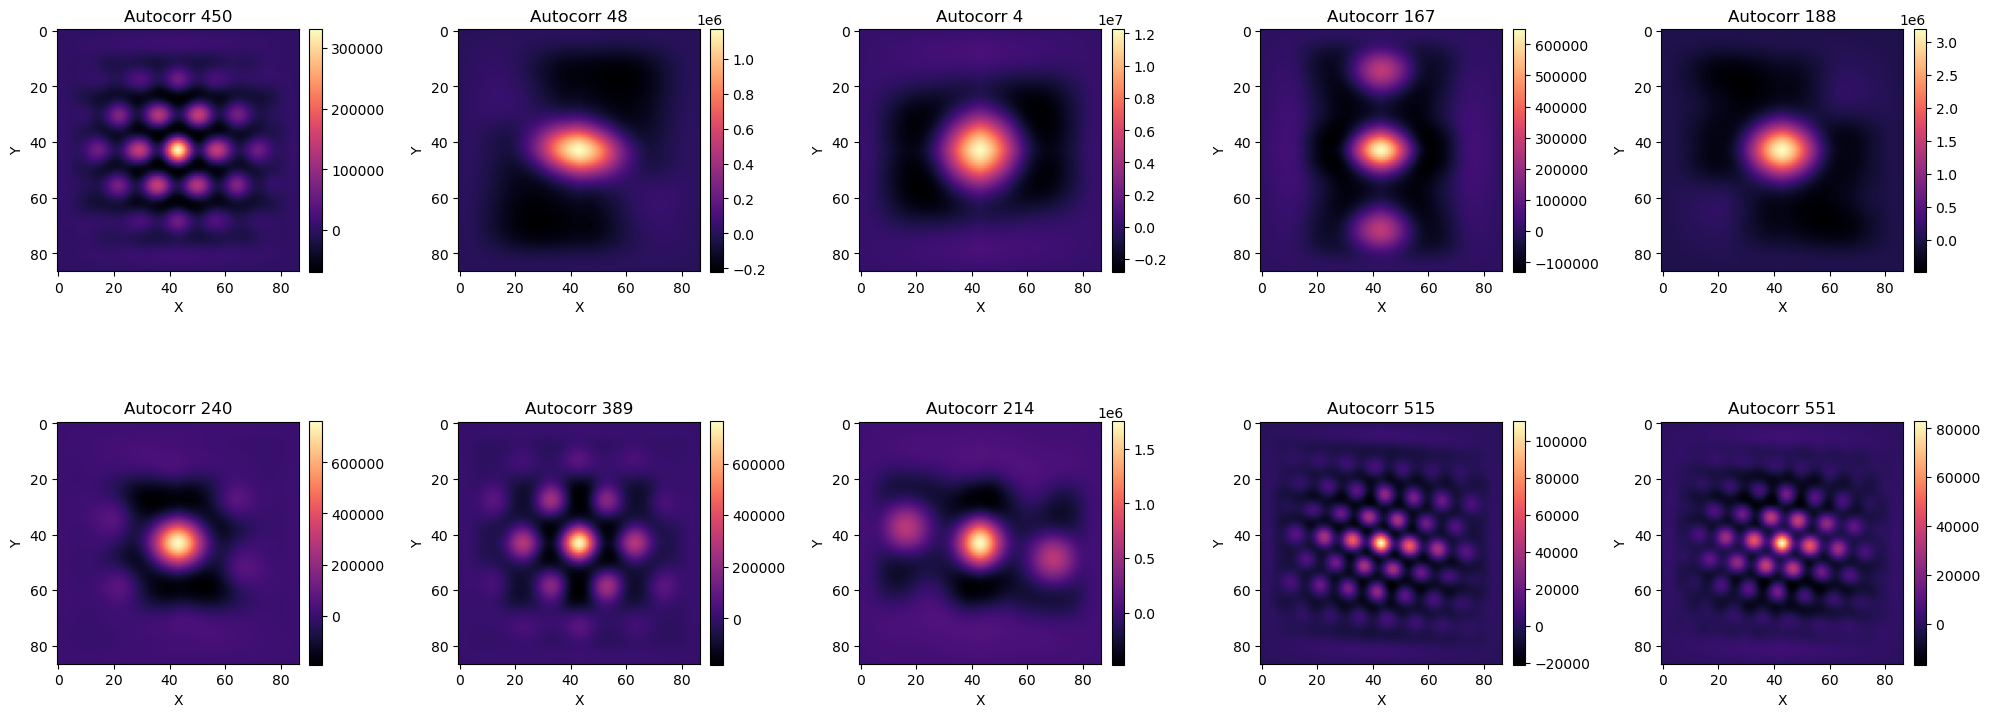

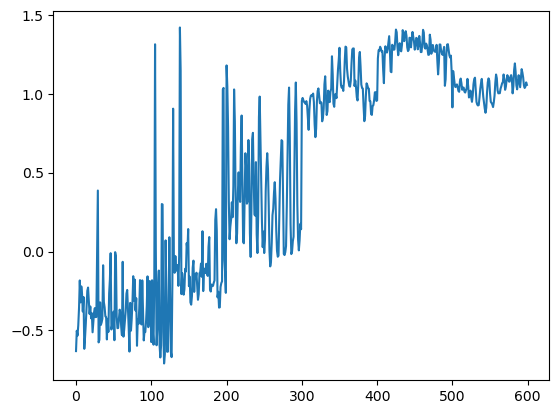

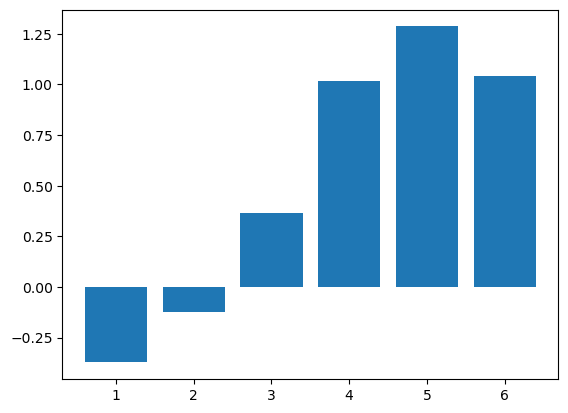

In [11]:
# inspect model output for oasis dataset

# here we reconstruct grids etc.

import numpy as np
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_correlograms
from inspect_data_grids import plot_gridness
from grid_cells import AutoCorr
from grid_cells import Gridness
from helper_fcts import load_dataset_and_GCs

# Visualize grids

# to check for what grid cells we might expect to record, let's estimate the reponse. 
# Assume a stimulus is anchored to a given grid cell population vector, i.e., 
# x,y coordinates on the torus/rate map. this we have saved when building the UCM
# Further assume, a hippocampal index (akin to a place cells), mediates connectivity
# betwee the full concept representation (elsewhere in cortex) and the map position on GCs. 
# If so, define a place cell-like Gaussian kernel to multiply with the grid cell PV. 
# For this we replicate the saved PV to all postions and filter with the HPC kernel. 
# So we estimate by Gaussian weighting of rate maps.
# We get an estimate of grid cells as they would be recorded if, and only if, 
# we calculated the placement of the stimuli correctly, i.e., only if
# the mapping algorithm respects the relations among the stimuli. 


# to analyse SYNTH comment/uncomment configname

# configname = 'BaseModel_Noise0'
configname = 'BaseModel_Noise0_SYNTH'

directory = 'datasets/oasis/'

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)

### even number please
N_plots = 10
cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)
###

noise = 0
broken = 0

sig = 1.5 # for Gauss HPC Kernel, 0.5 small, 1.5 big
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1  # make range of sigmas, like different sized place fields
#sigr = np.array([2])*1 # overrides the above, gives nicer grids at small scales, essentially smoothes the grids a bit, like experimental analysis

print('#####',sigr)

cleanup = 0 # optional an not really used

# important to use PVs_xy_data here, to preserve possibility of mismatch
dataset_GCs = make_data_grids(N_GCs, res, Stims, PVs_xy_data, PVs, sig, sigr, cleanup)

plot_data_grids(dataset_GCs, N_plots, cells2show)

corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
corr        = corr.data  # because this is a masked array
plot_correlograms(corr, N_plots, cells2show)
G           = Gridness(corr, x, y, N_GCs)
plot_gridness(G)

filename = f"datasets/oasis/{configname}_G_Corr_dataGCs.npz"
np.savez(filename, correlograms=corr, xed=x, yed=y, G=G, dataset_GCs=dataset_GCs)


In [12]:
# we can look at all recoverd data grids. They are a proxy for recordings
# that is, if real world relations correspond to neural-space relations these grids look good

import numpy as np
from inspect_data_grids import save_all_data_grids

#configname = 'BaseModel_Noise0'
configname = 'BaseModel_Noise0_SYNTH'
directory = 'datasets/oasis/'

filename = f"datasets/oasis/{configname}_G_Corr_dataGCs.npz"
tmp = np.load(filename)
dataset_GCs = tmp["dataset_GCs"]

#save_all_data_grids(dataset_GCs, subfolder="datasets/oasis/data_grids/data_grids_oasis")
save_all_data_grids(dataset_GCs, subfolder="datasets/oasis/data_grids/data_grids_synth")
#save_all_data_grids(GCs, subfolder="datasets/oasis/data_grids/input_grids")

Saving 600 grid cell maps to 'datasets/oasis/data_grids/data_grids_synth'...
Done.


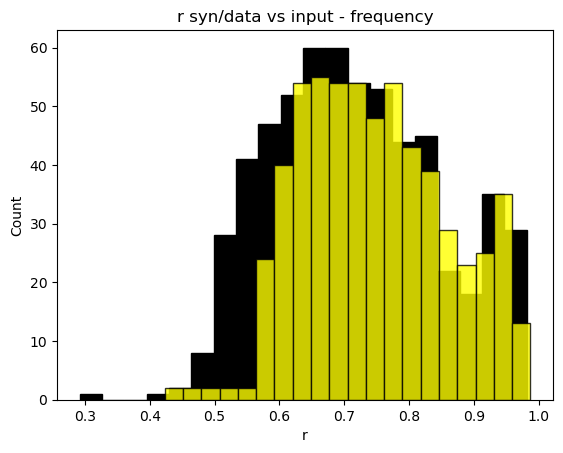

In [15]:
# correlate input and data grids
# to run this, first rerun above with synthetic oasis data

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift as nd_shift

#configname1 = 'BaseModel_Noise0'
#configname2 = 'BaseModel_Noise0_SYNTH'

directory = 'datasets/oasis/'

configname1 = 'BaseModel_Noise0'
filename = f"datasets/oasis/{configname1}_G_Corr_dataGCs.npz"
tmp1 = np.load(filename)
corr = tmp1["correlograms"]
x = tmp1["xed"]
y = tmp1["yed"]
g = tmp1["G"]
dataset_GCs = tmp1["dataset_GCs"]
Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname1,directory)

configname2 = 'BaseModel_Noise0_SYNTH'
filename = f"datasets/oasis/{configname2}_G_Corr_dataGCs.npz"
tmp2 = np.load(filename)
corr_SYN = tmp2["correlograms"]
x_SYN = tmp2["xed"]
y_SYN = tmp2["yed"]
g_SYN = tmp2["G"]
dataset_GCs_SYN = tmp2["dataset_GCs"]
Stims_SYN, PVs_SYN, PVs_xy_SYN, PVs_xy_data_SYN, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname2,directory)

dx = np.median(PVs_xy[:,0] - PVs_xy_data[:,0])
dy = np.median(PVs_xy[:,1] - PVs_xy_data[:,1])
shift = np.array([int(np.round(dx)), int(np.round(dy))])

dx_SYN = np.median(PVs_xy_SYN[:,0] - PVs_xy_data_SYN[:,0])
dy_SYN = np.median(PVs_xy_SYN[:,1] - PVs_xy_data_SYN[:,1])
shift_SYN = np.array([int(np.round(dx_SYN)), int(np.round(dy_SYN))])

# small shift to account for offset during mapping

rec_shifted = np.zeros_like(dataset_GCs)
rec_shifted_SYN = np.zeros_like(dataset_GCs_SYN)

for i in range(N_GCs):
    rec_shifted[:,:,i] = nd_shift(dataset_GCs[:,:,i], shift=[dy, dx], mode='constant', cval=0)
    rec_shifted_SYN[:,:,i] = nd_shift(dataset_GCs_SYN[:,:,i], shift=[dy_SYN, dx_SYN], mode='constant', cval=0)
    # now correlate rec_shifted with GCs[:,:,i] ignoring zero-padded border

# now corr for all cells, then hist
coeffi     = np.zeros([N_GCs,1])
coeffi_SYN = np.zeros([N_GCs,1])
for i in range(N_GCs):
    A = GCs[5:45,5:45,i]
    B = rec_shifted[5:45,5:45,i]
    C = rec_shifted_SYN[5:45,5:45,i]
    r1 = np.corrcoef(A.flatten(), B.flatten())[0,1]
    r2 = np.corrcoef(A.flatten(), C.flatten())[0,1]
    coeffi[i]     = r1
    coeffi_SYN[i] = r2

filename = f"datasets/oasis/'BaseModel_Noise0_corrcoef.npz"
np.savez(filename, corrcoef_syn=coeffi_SYN, corrcoef_data=coeffi,)

plt.hist(coeffi, 
    bins=20,
    alpha=1,          
    edgecolor='black',  
    color='black')    
#plt.title(f"r frequency - data vs input")
plt.xlabel("r")
plt.ylabel("Count")
#plt.show()

plt.hist(coeffi_SYN,
    bins=20,
    alpha=0.8,          
    edgecolor='black',  
    color='yellow')
plt.title("r syn/data vs input - frequency")
plt.xlabel("r")
plt.ylabel("Count")
plt.show()


  0%|          | 0/10 [00:00<?, ?it/s]

[2.9 2.6 2.3 2.  1.7 1.4]


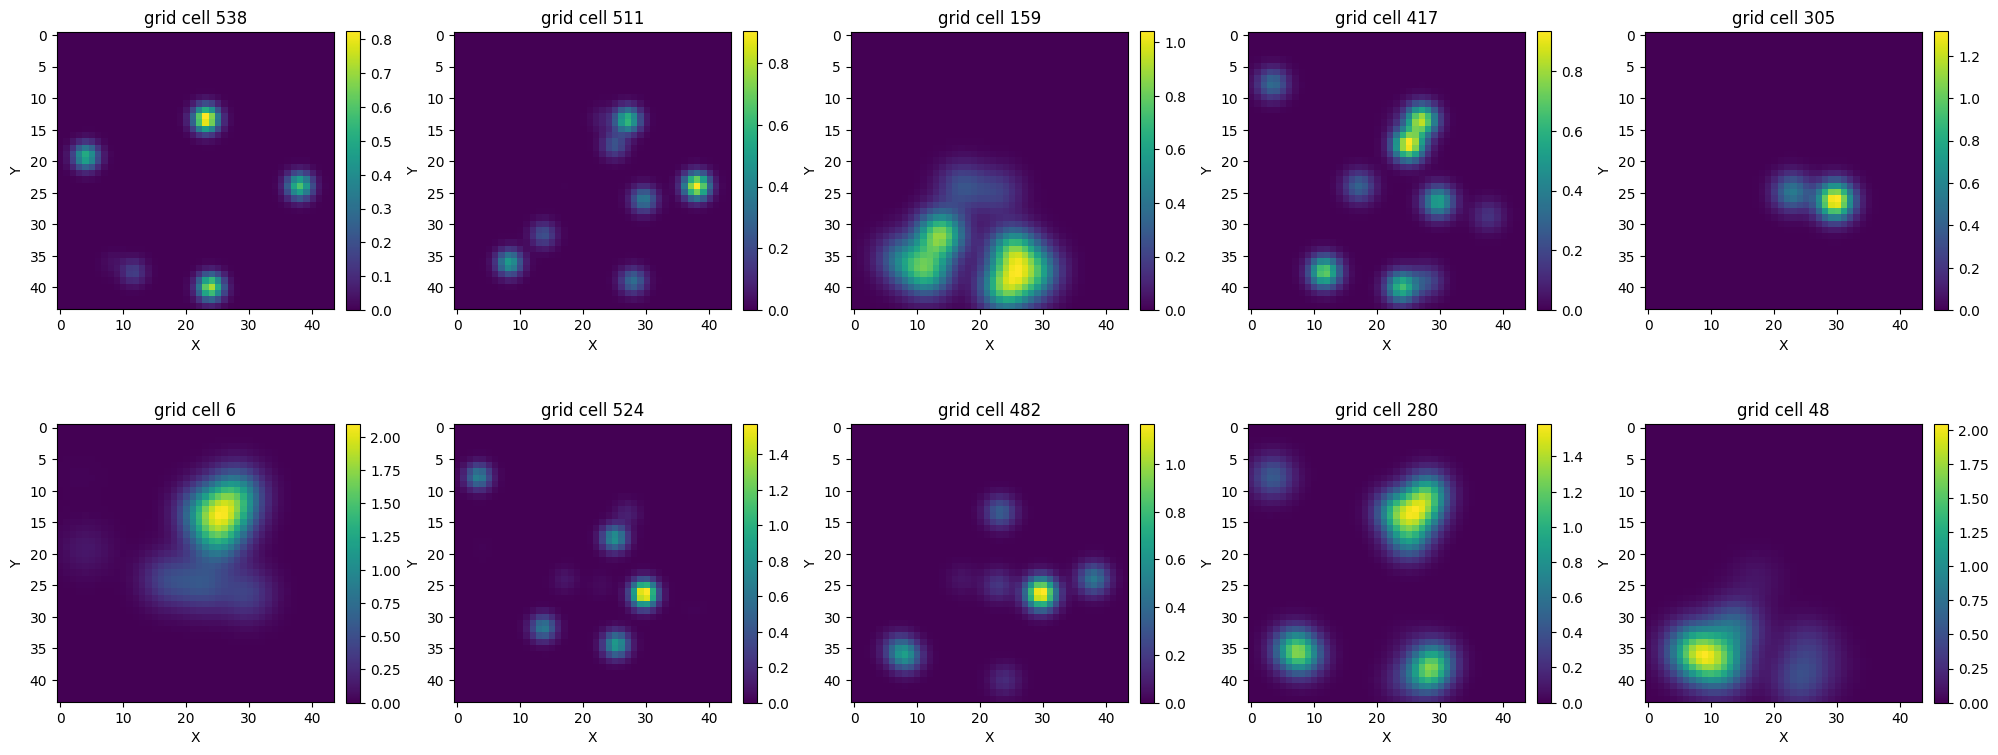

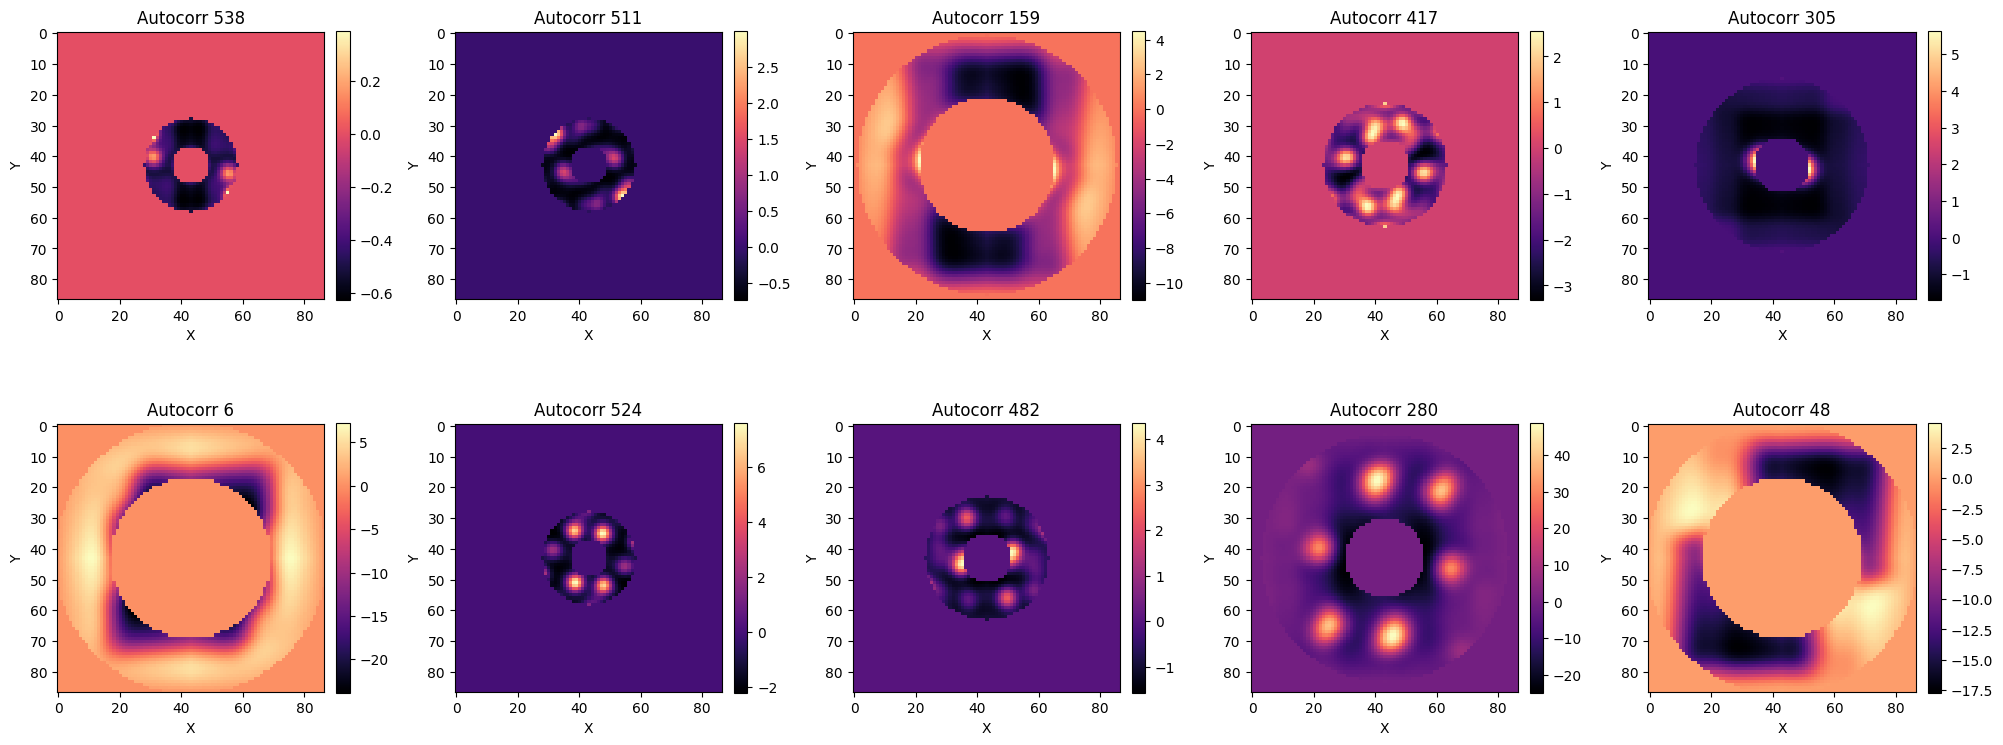

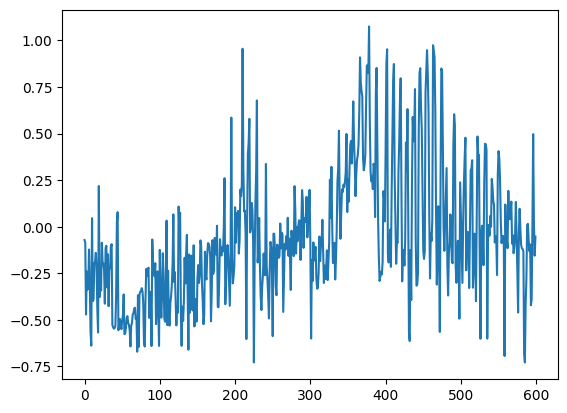

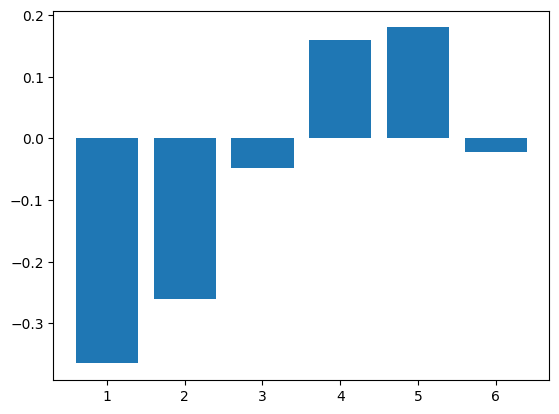

[2.9 2.6 2.3 2.  1.7 1.4]


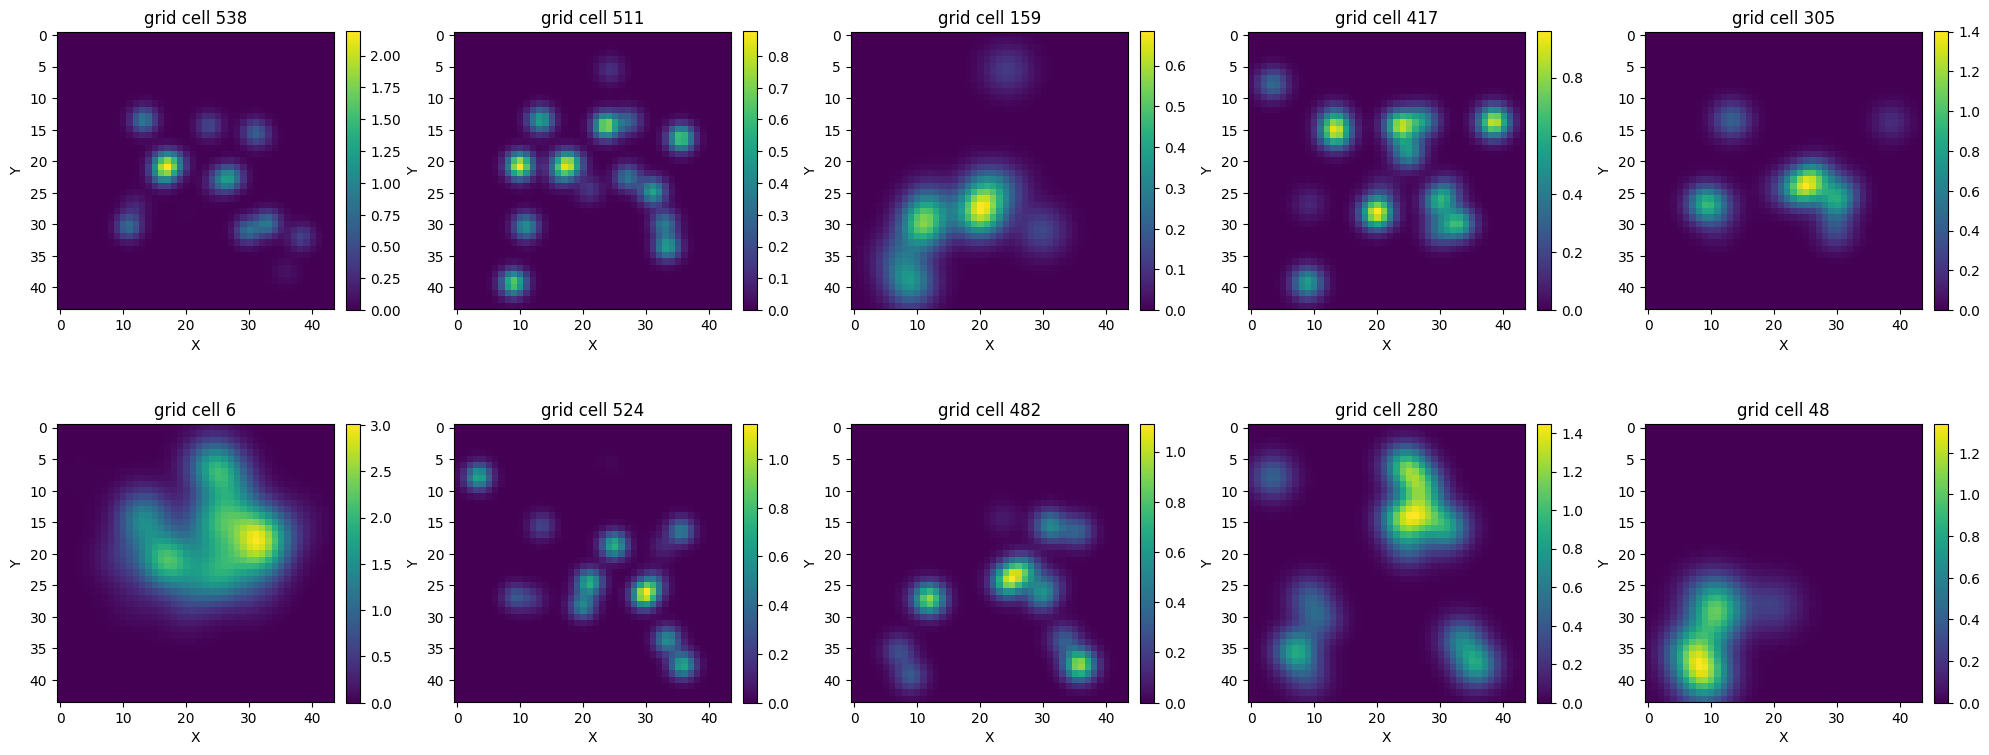

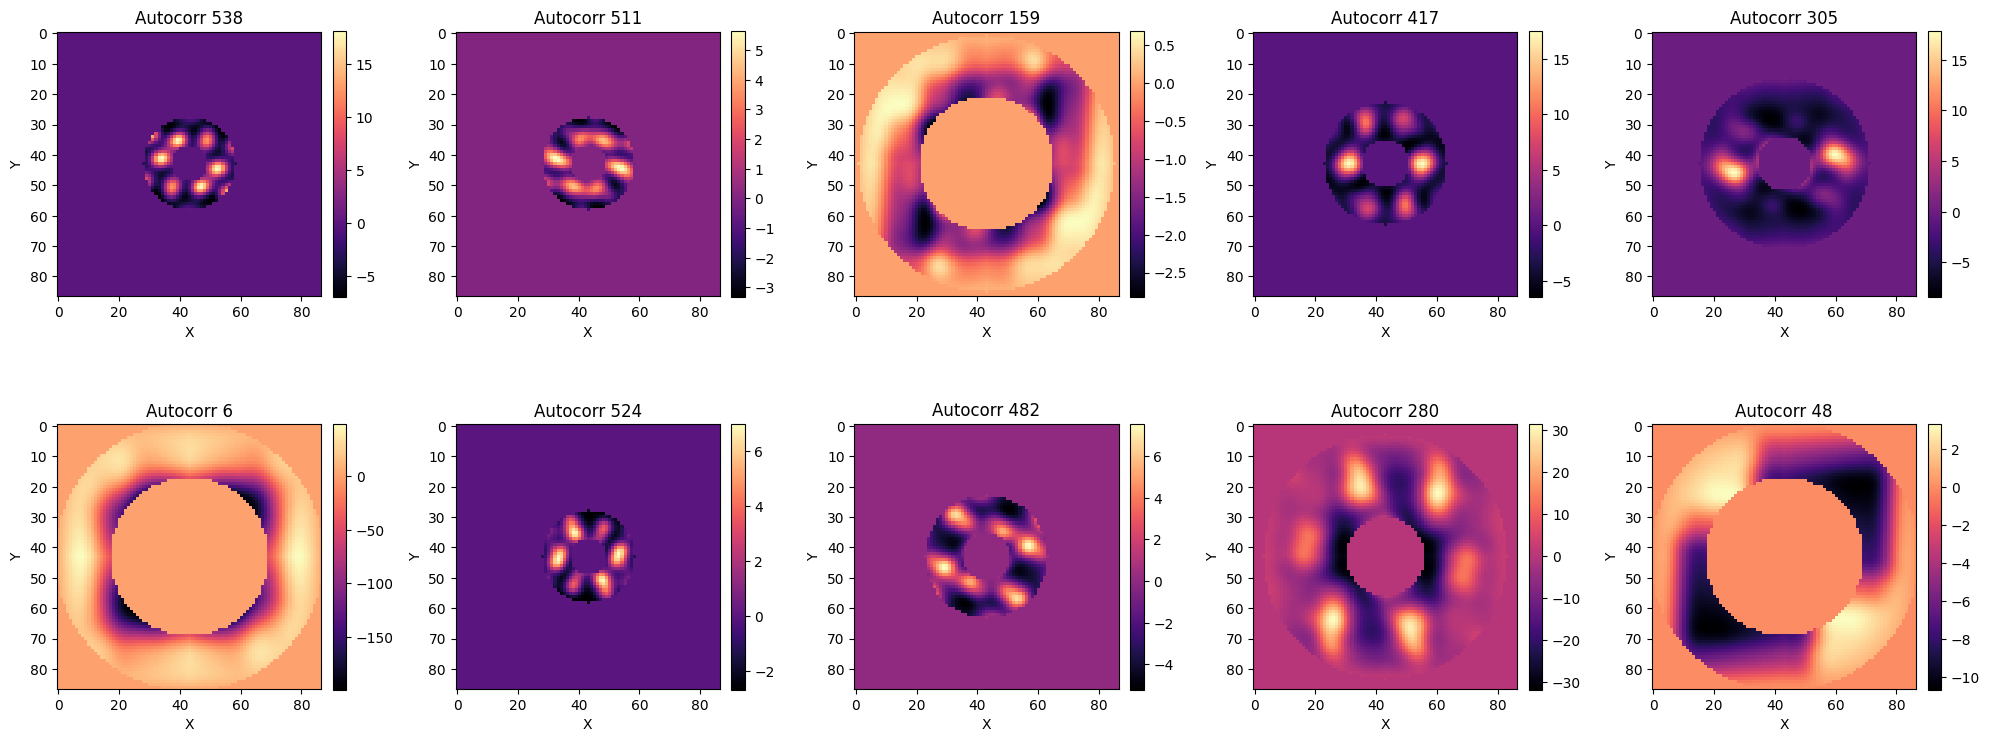

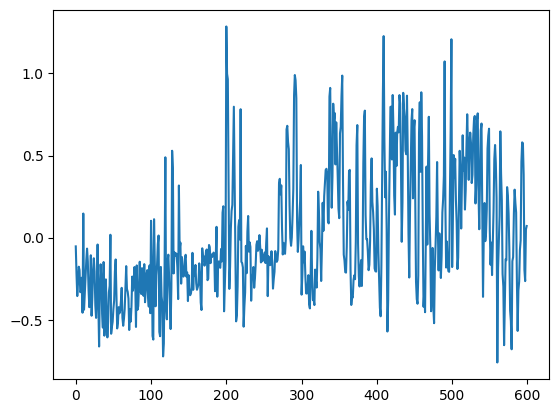

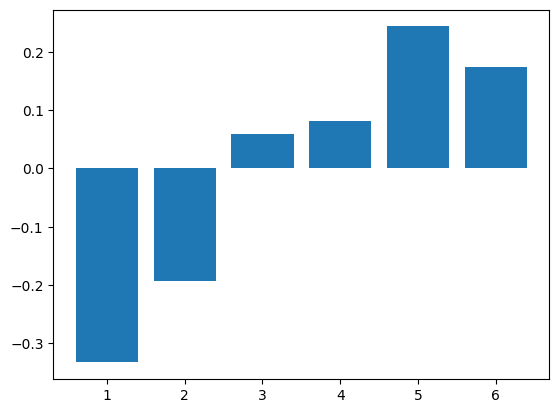

[2.9 2.6 2.3 2.  1.7 1.4]


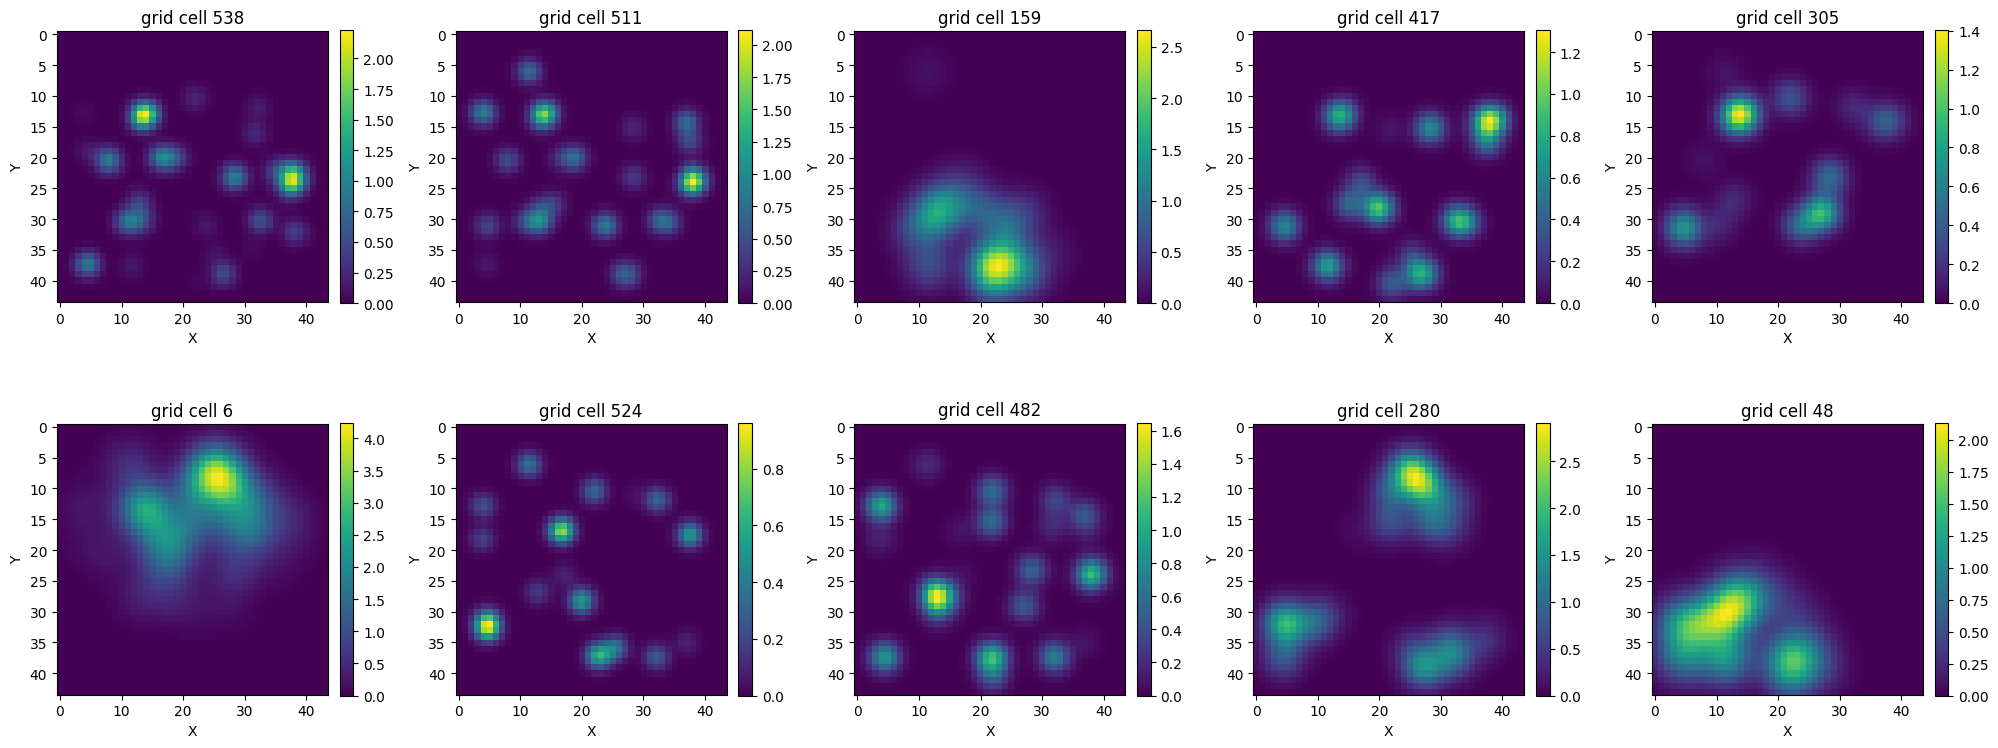

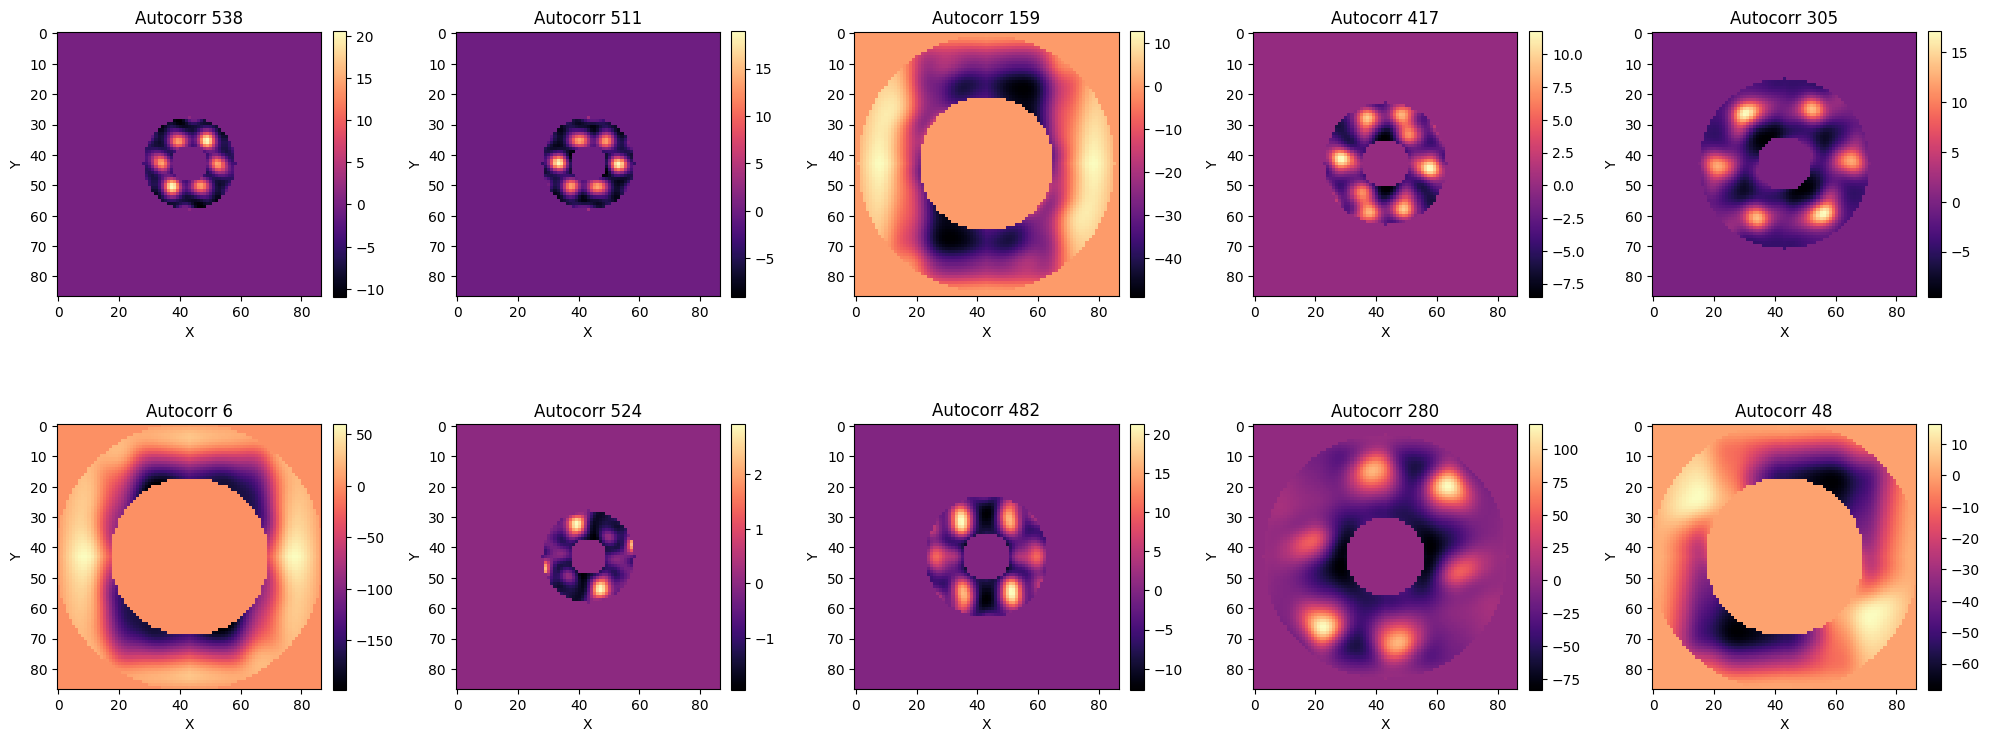

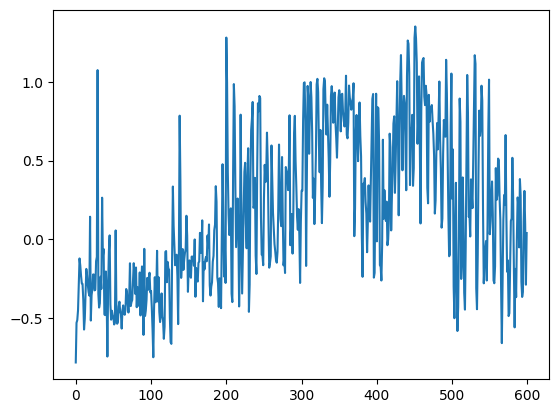

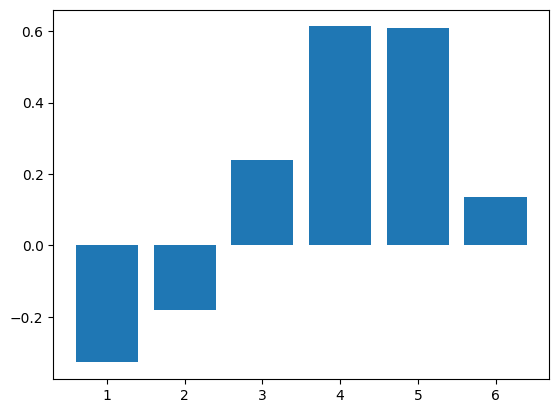

[2.9 2.6 2.3 2.  1.7 1.4]


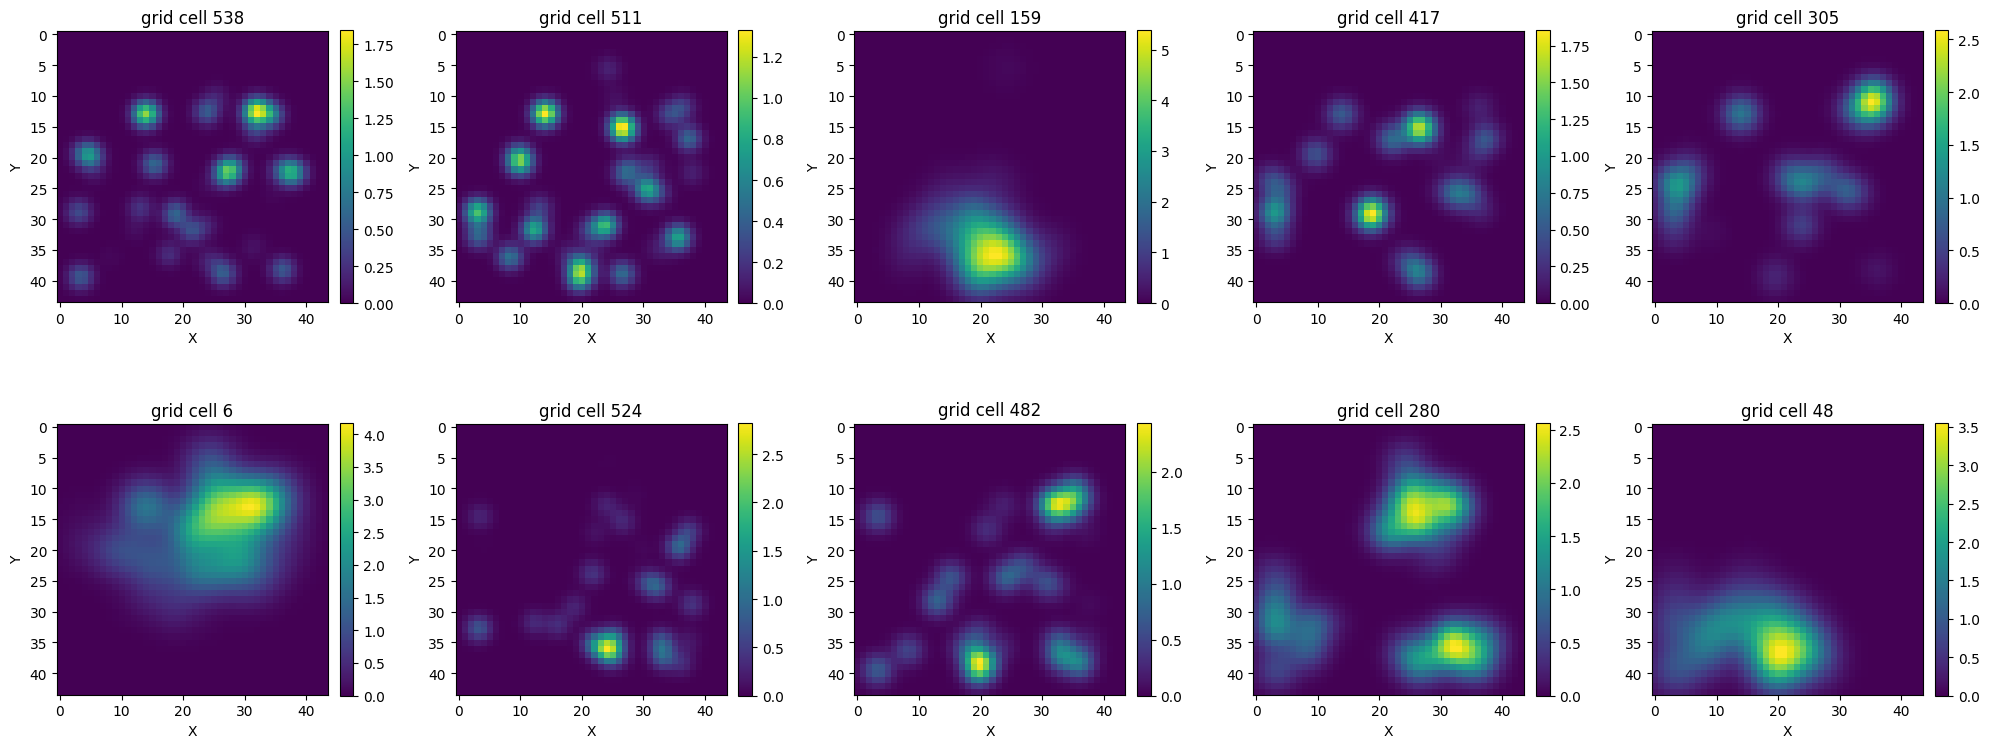

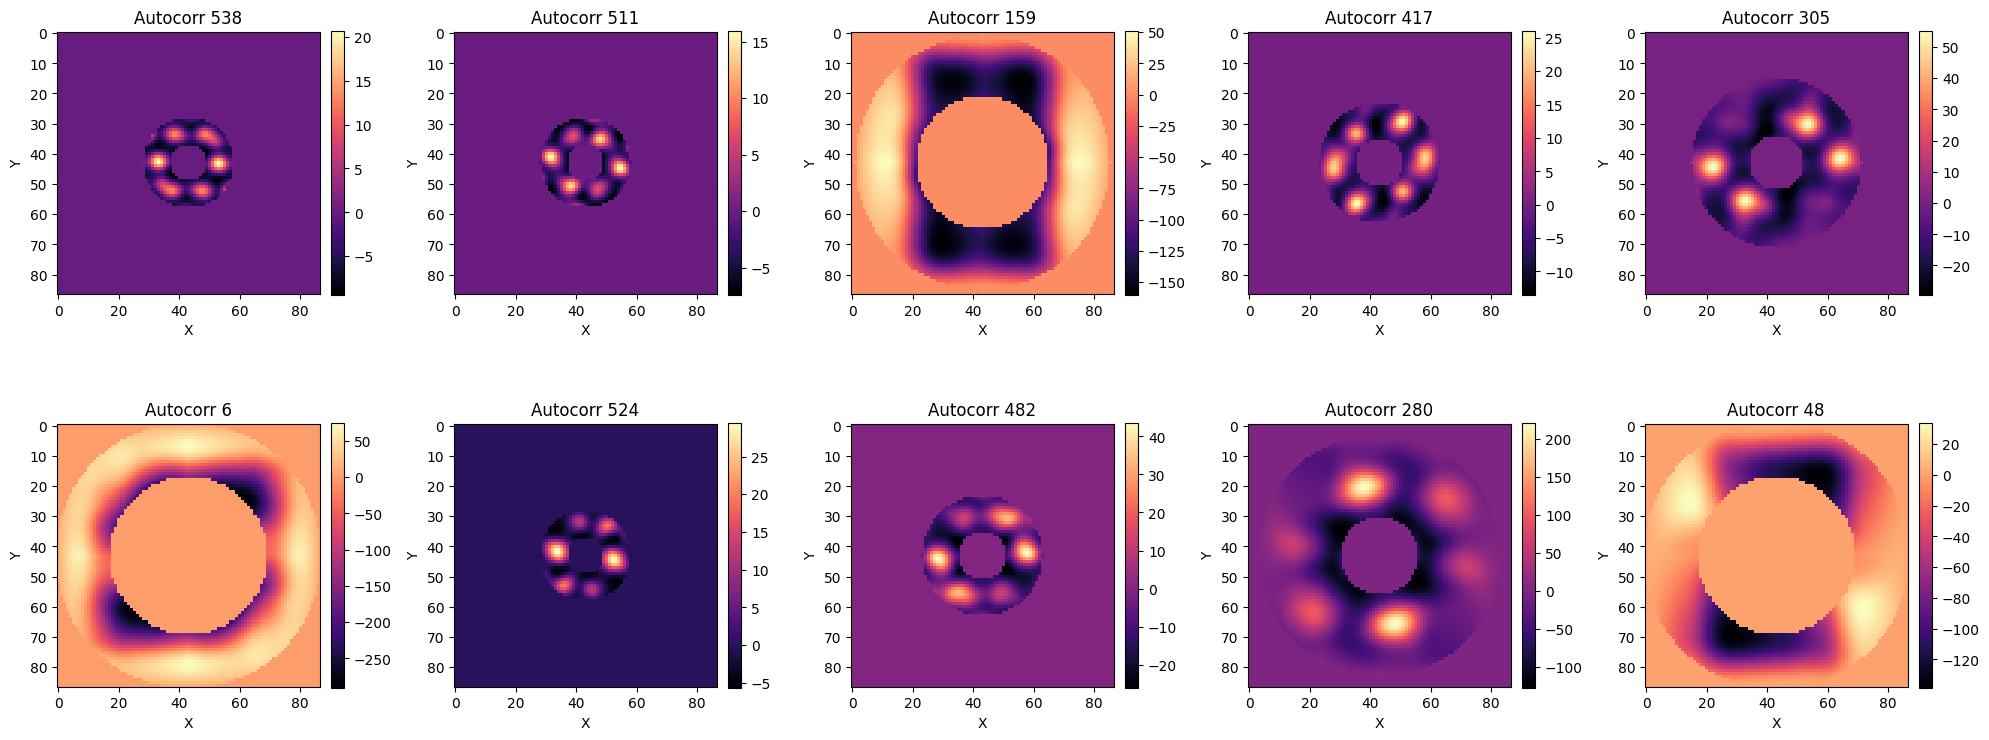

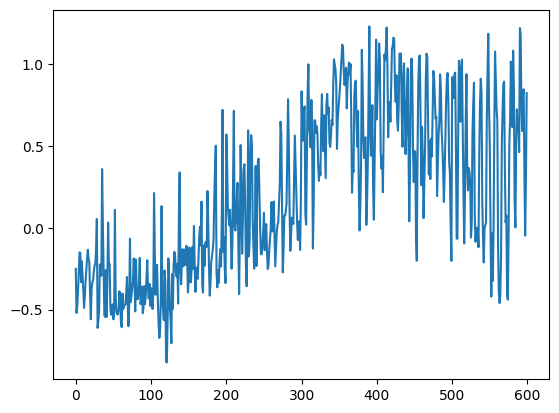

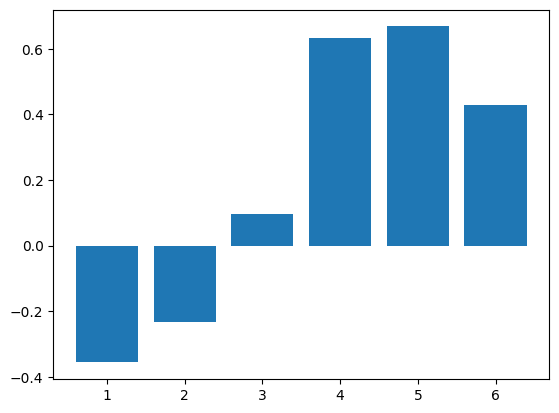

[2.9 2.6 2.3 2.  1.7 1.4]


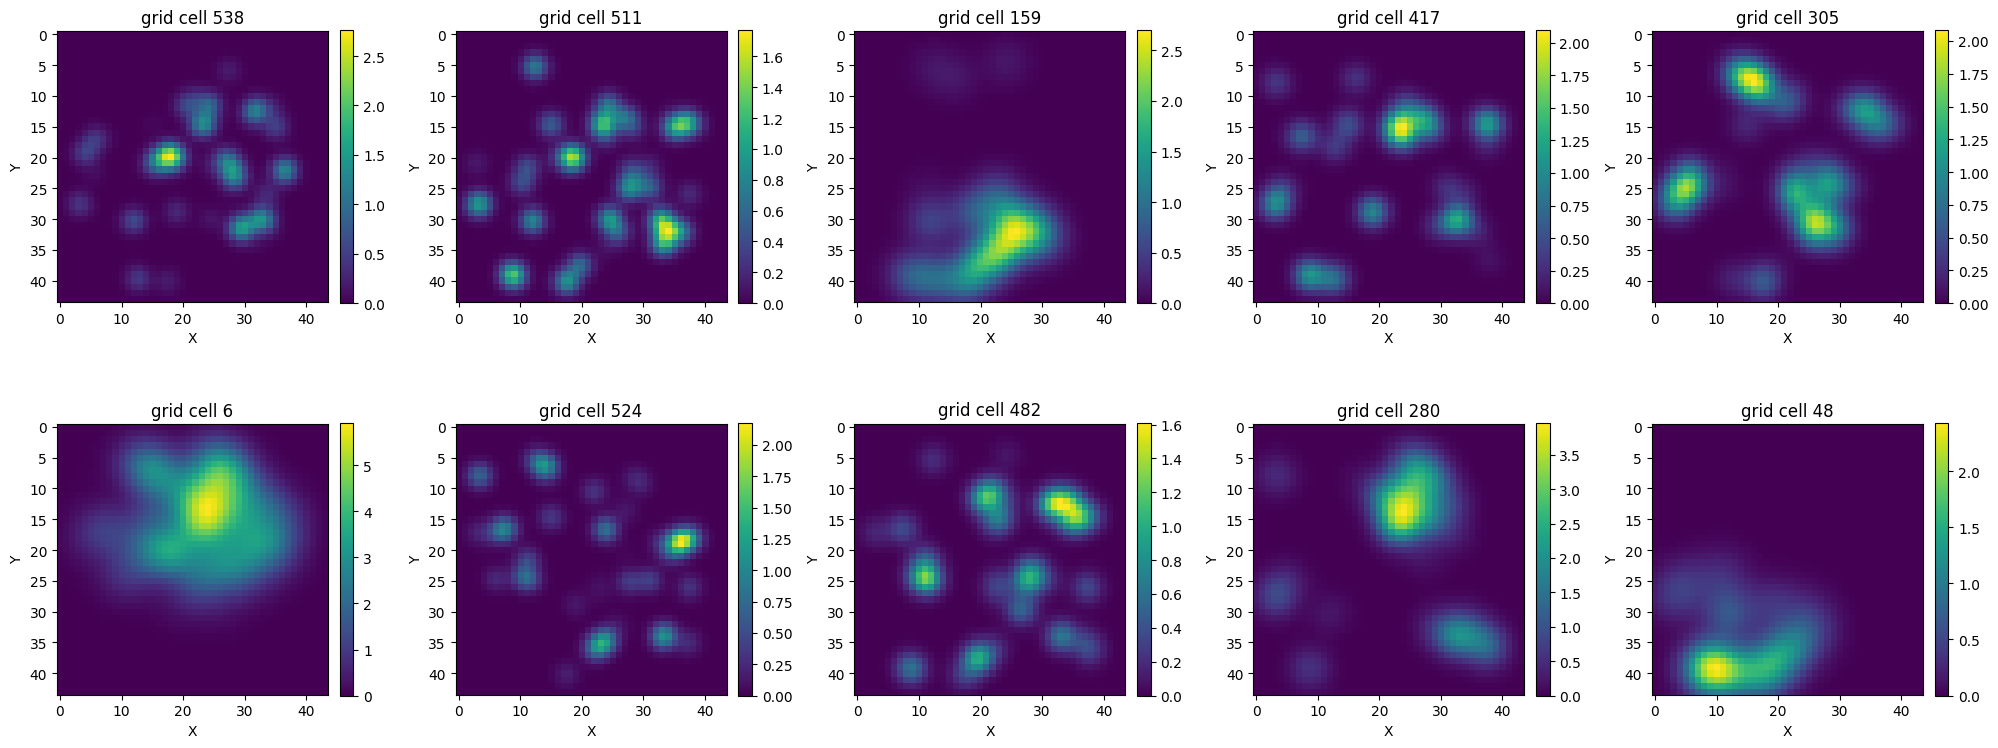

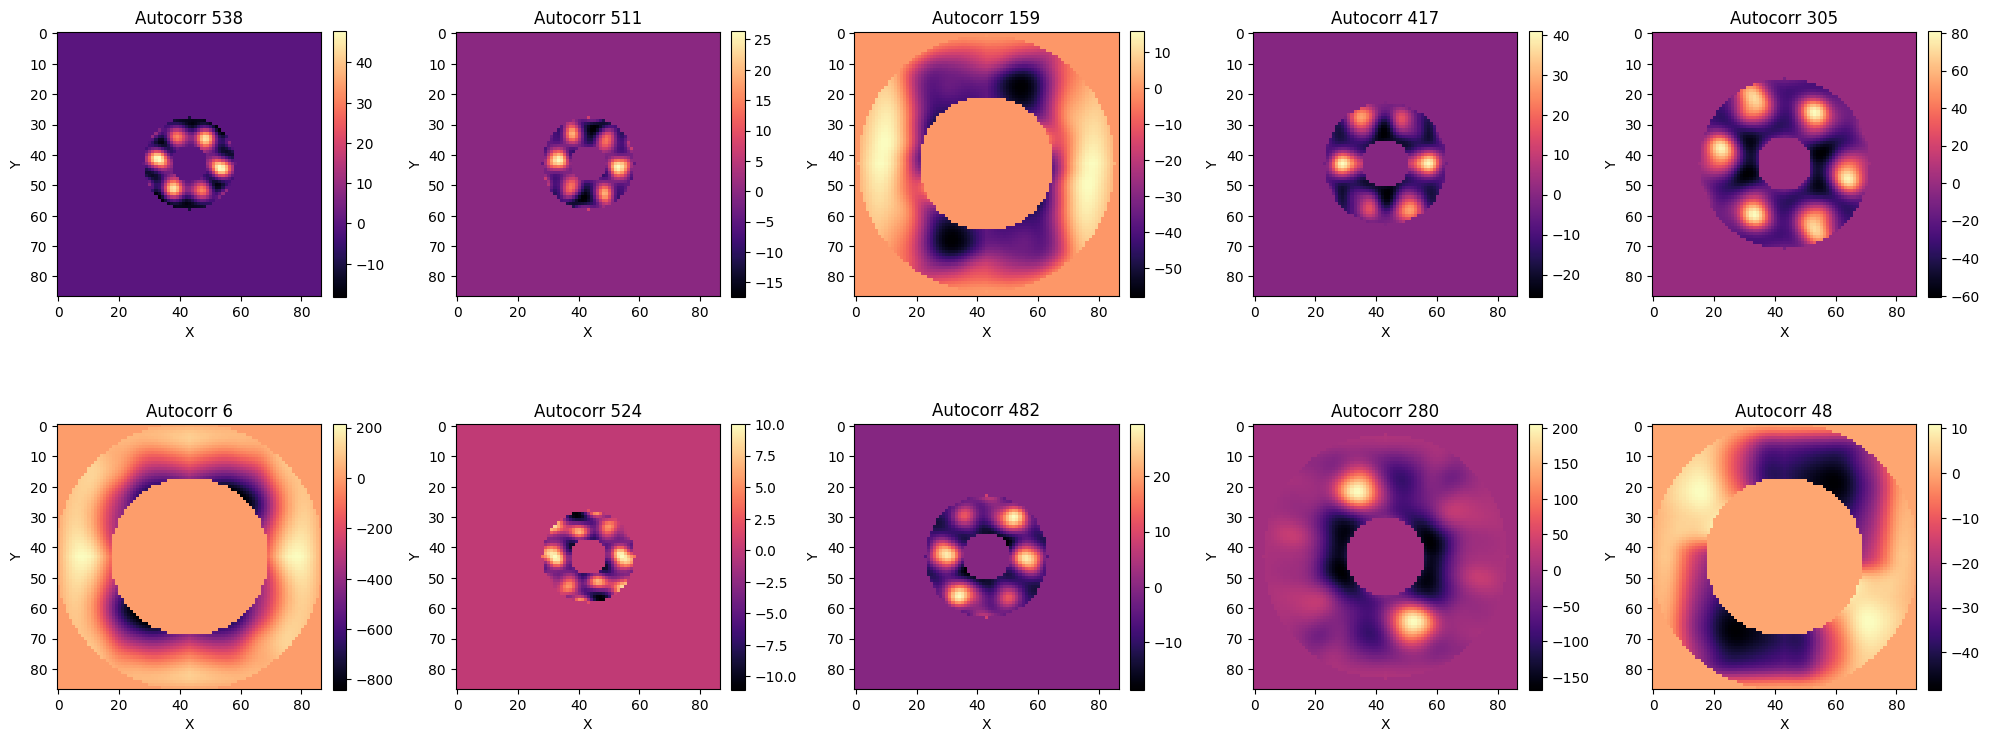

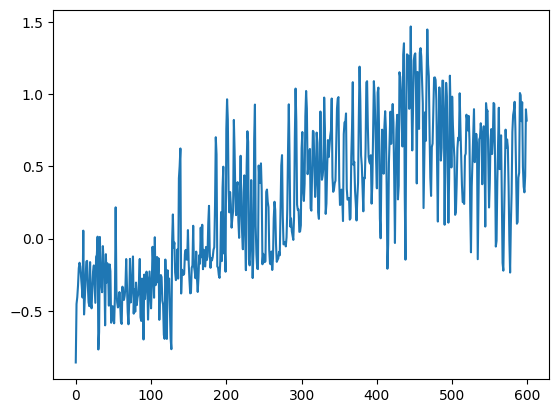

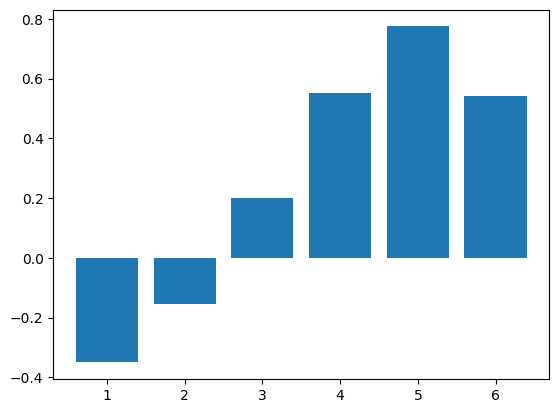

[2.9 2.6 2.3 2.  1.7 1.4]


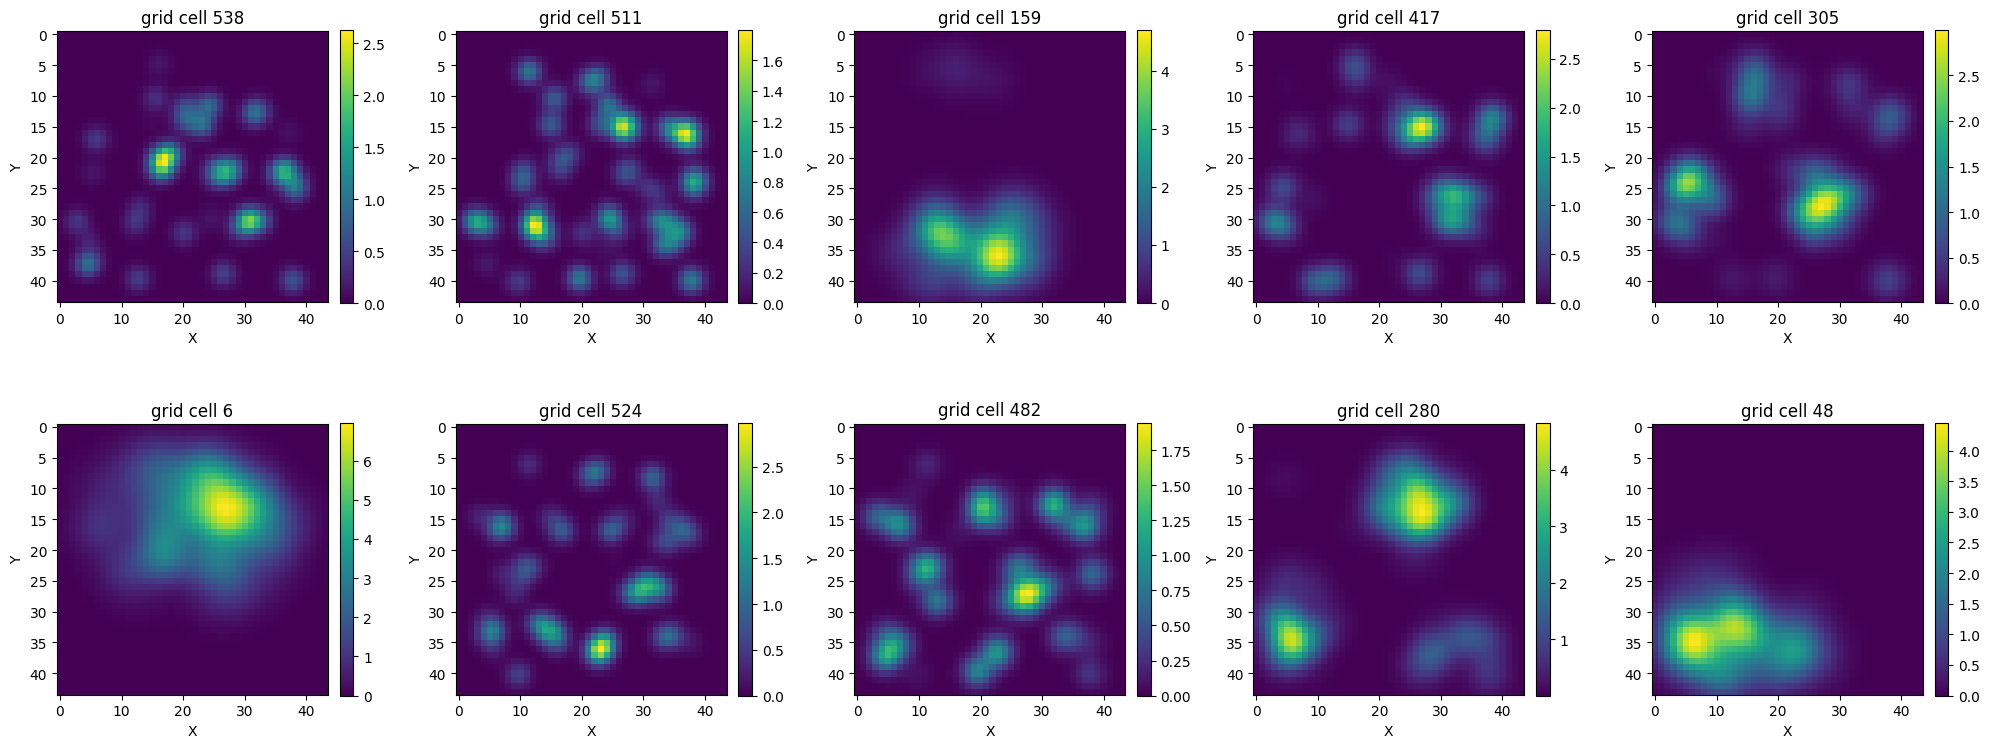

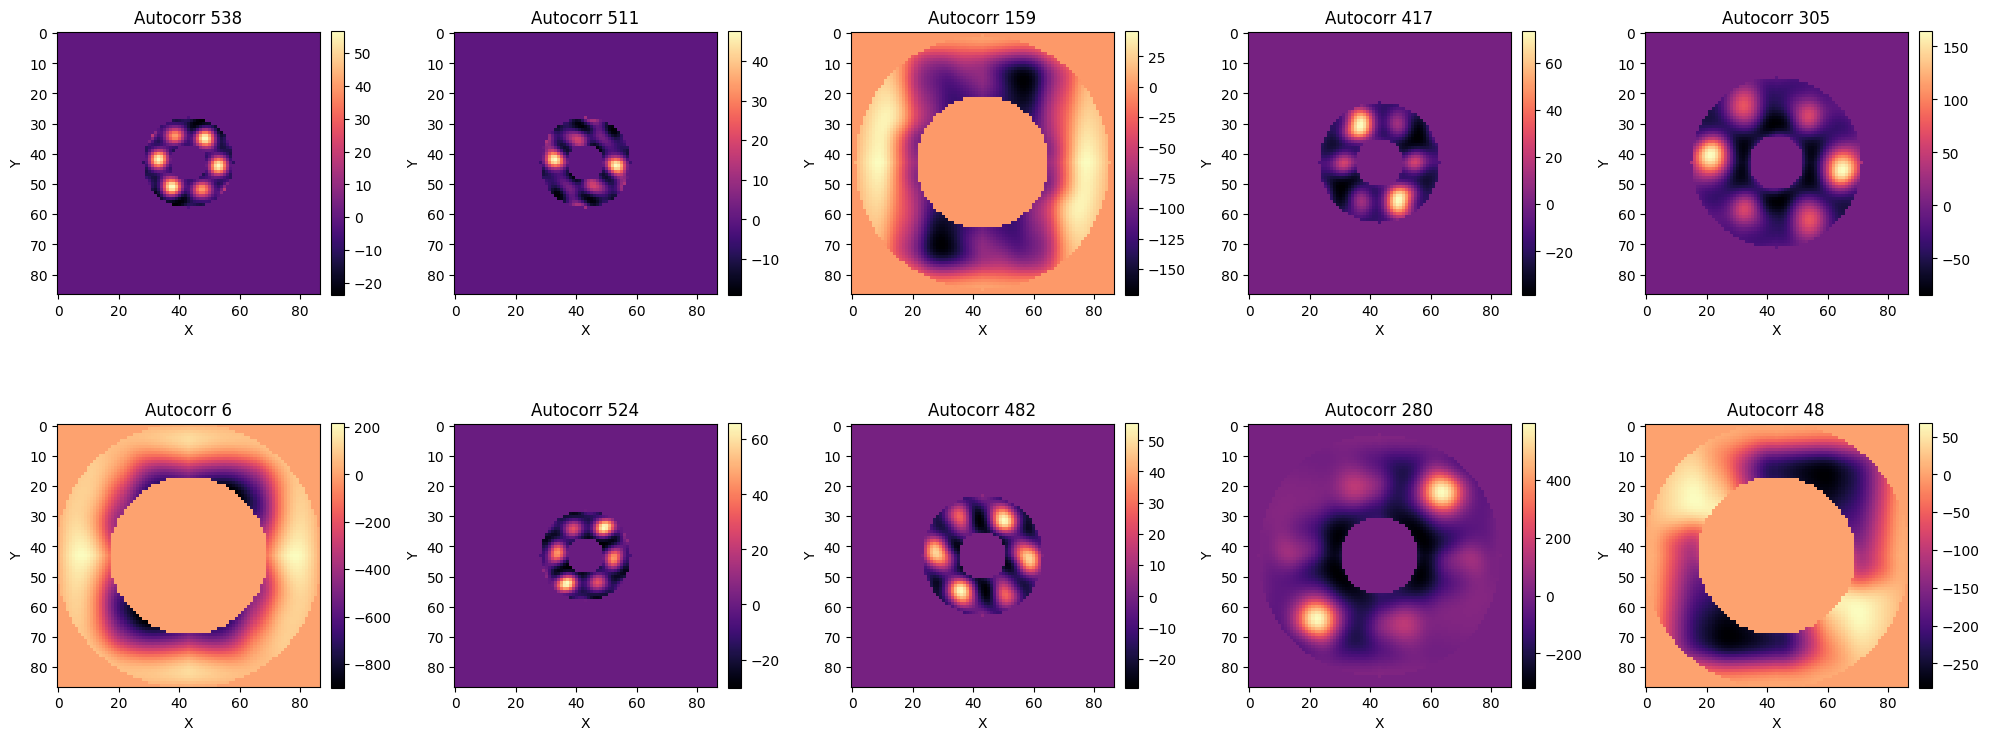

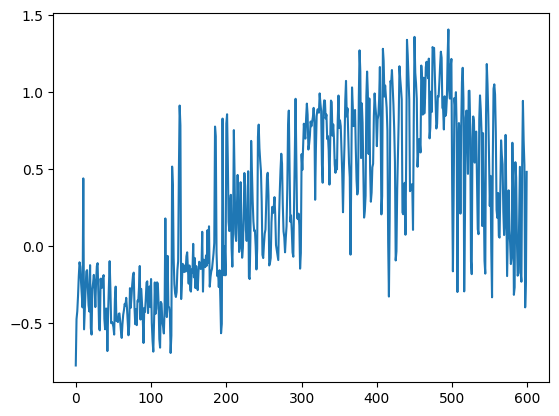

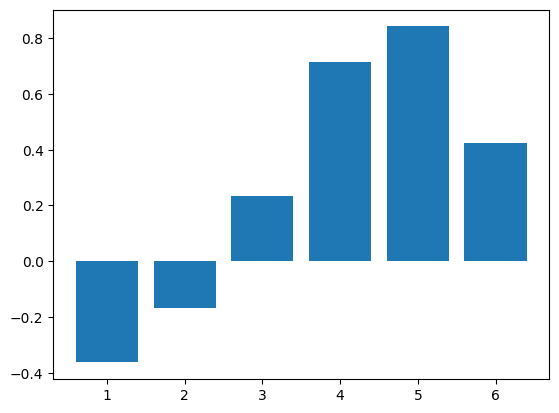

[2.9 2.6 2.3 2.  1.7 1.4]


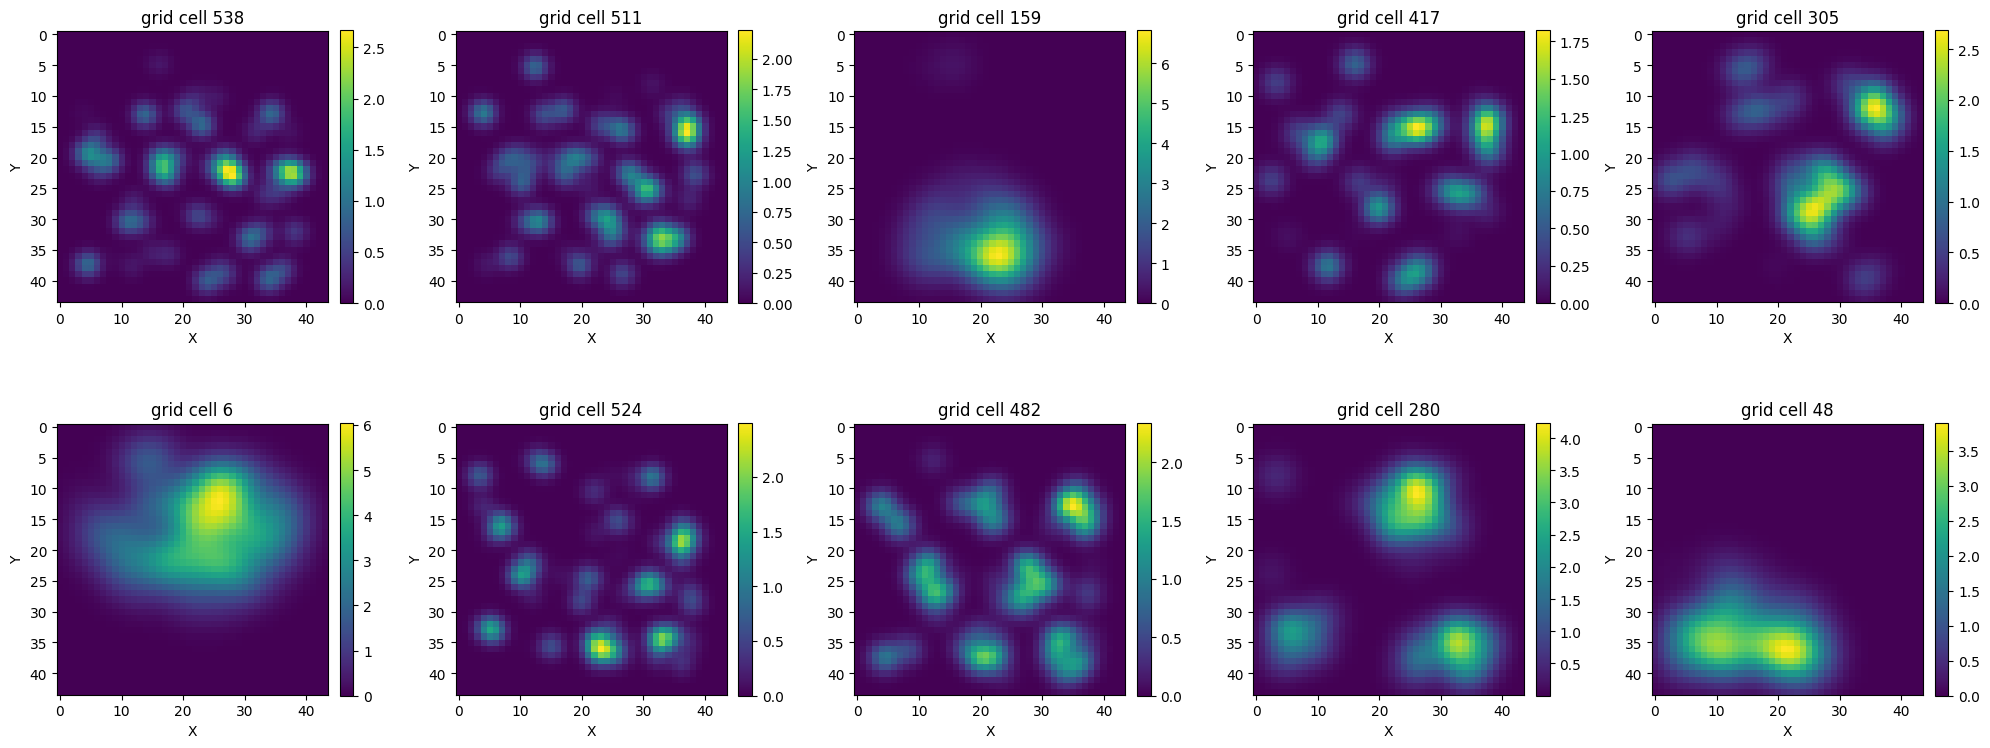

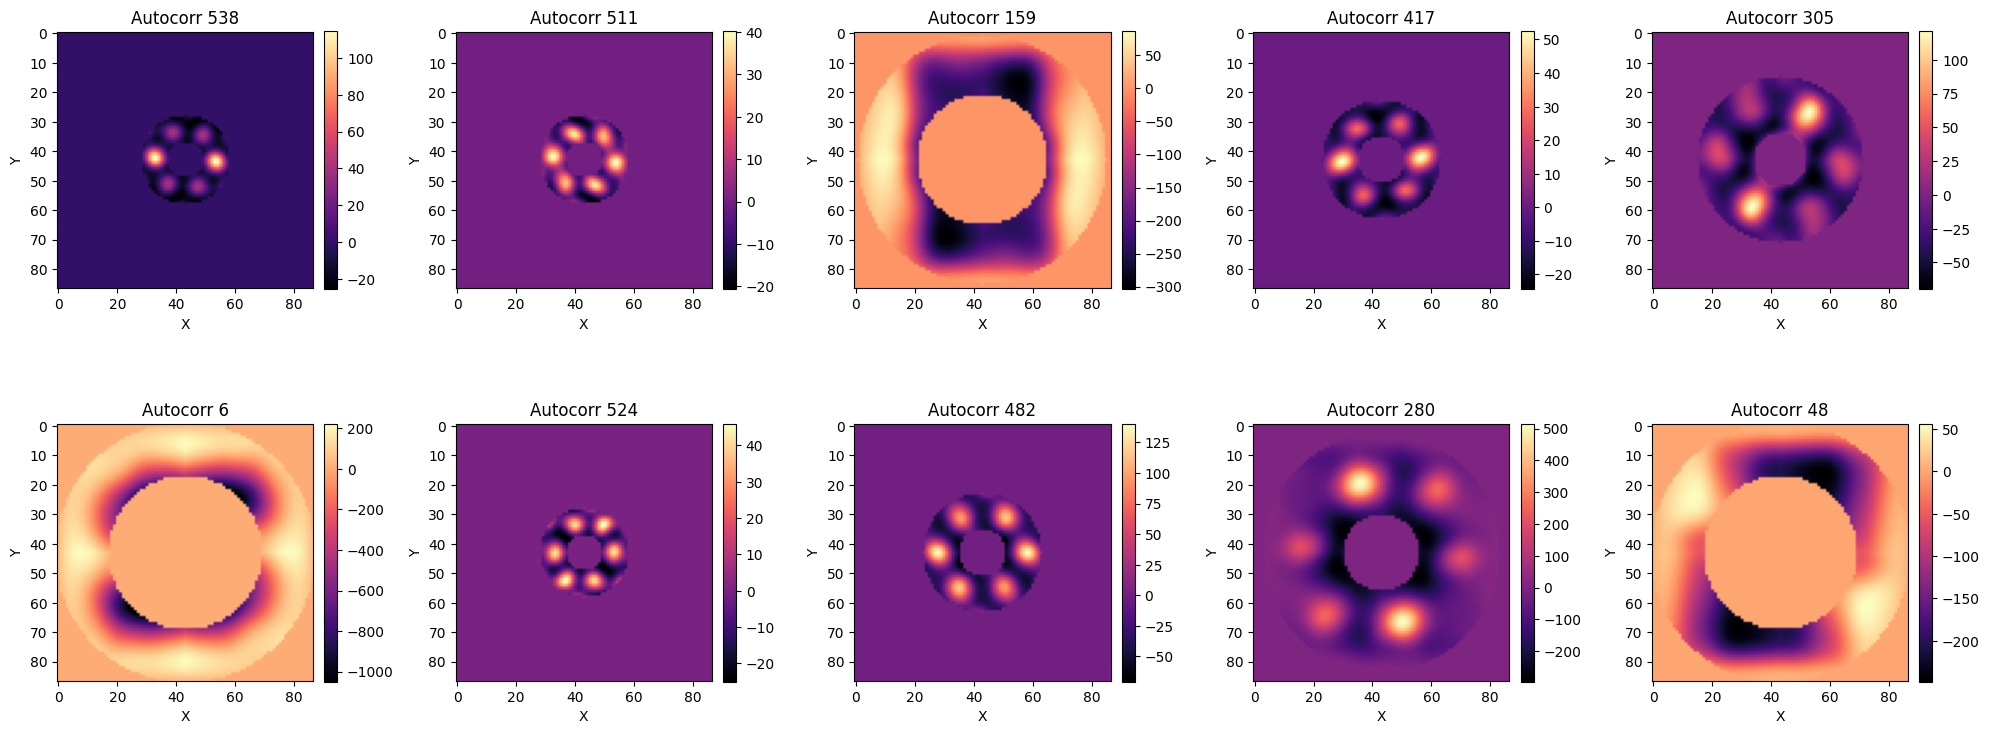

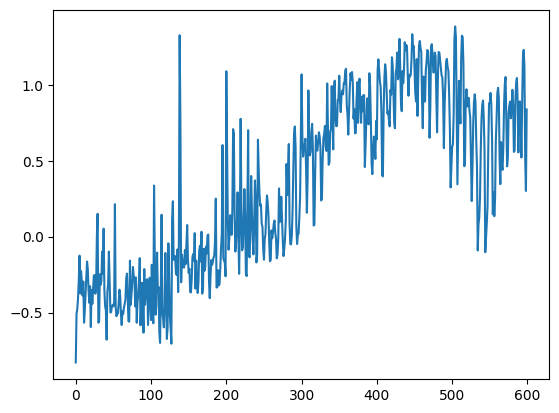

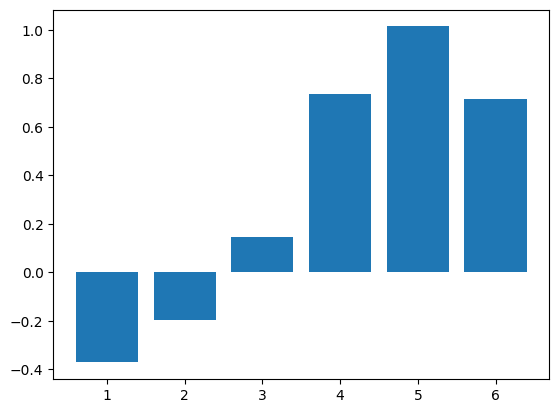

[2.9 2.6 2.3 2.  1.7 1.4]


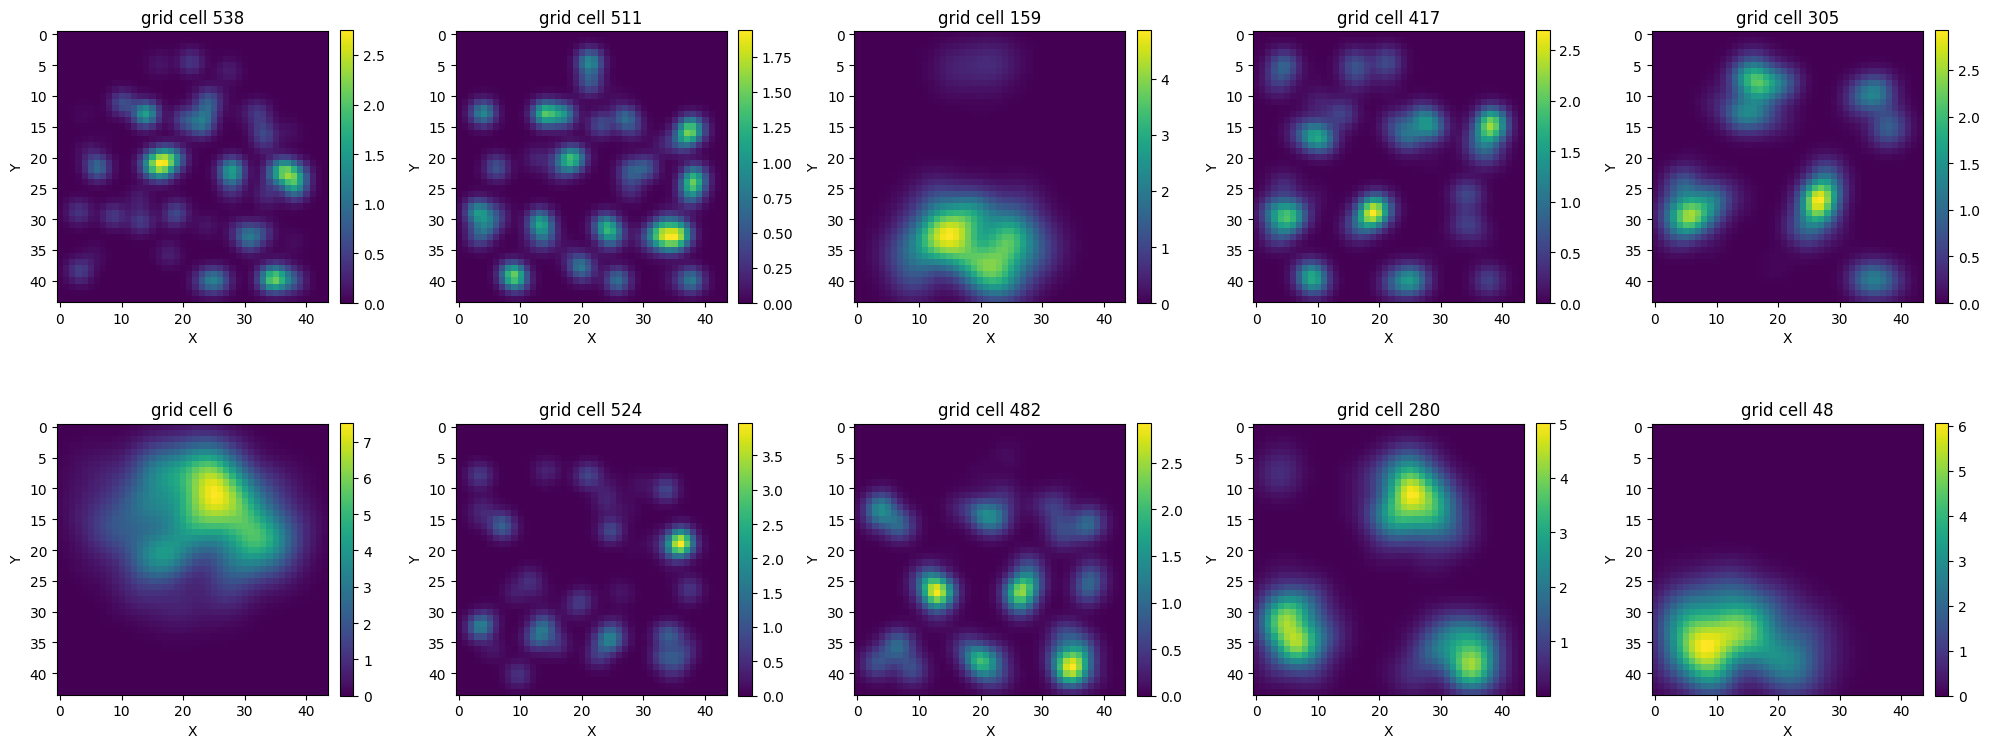

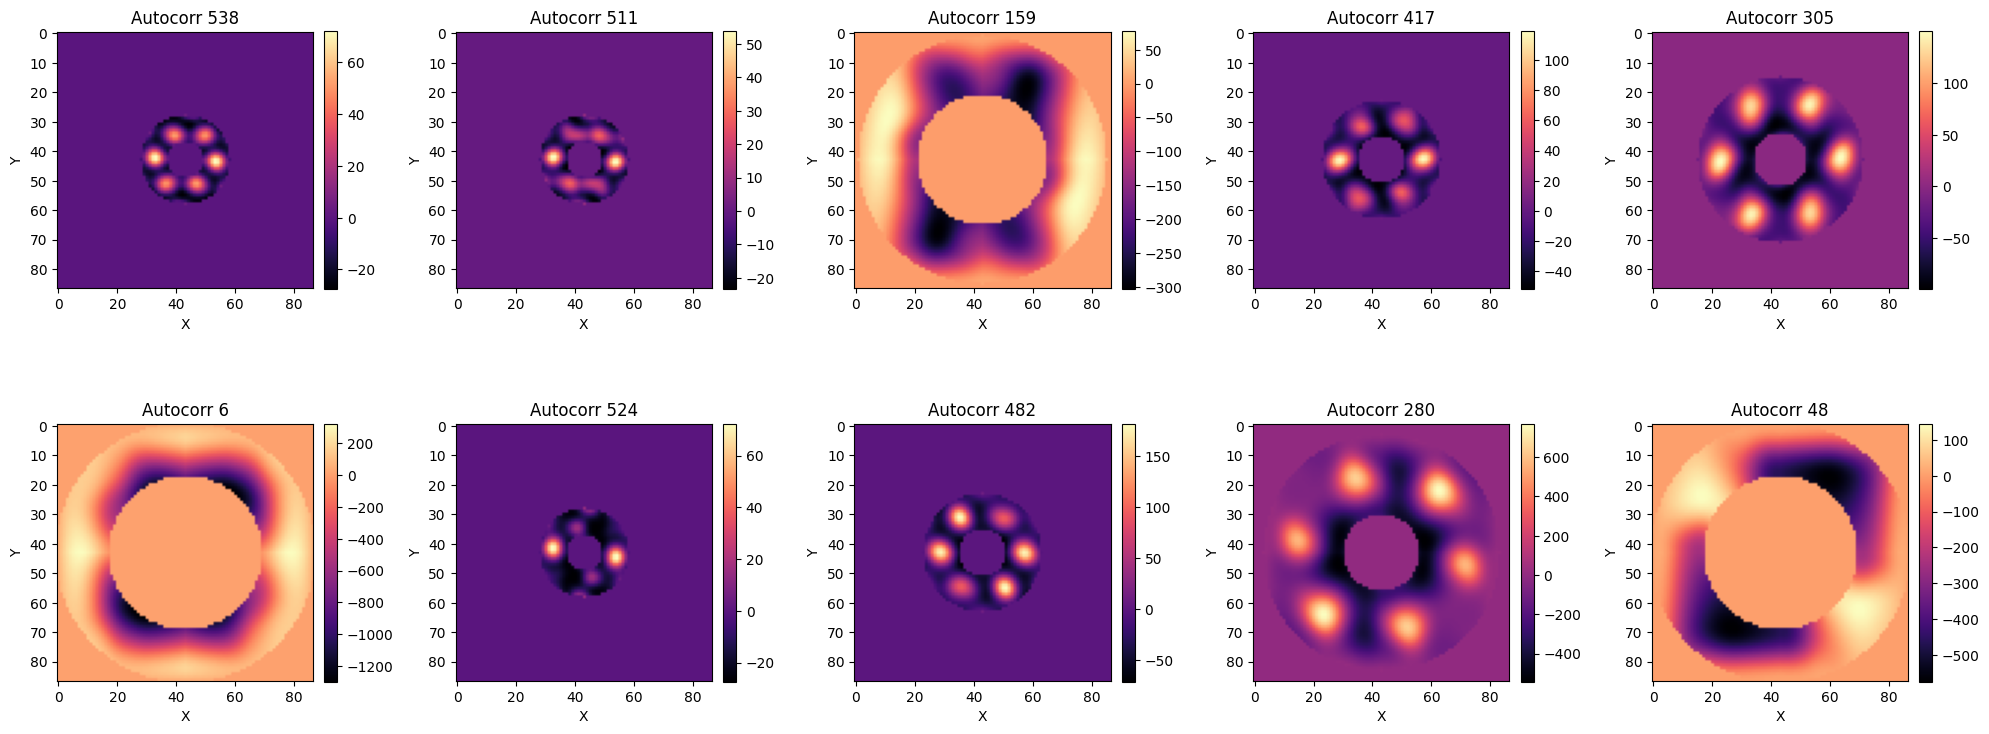

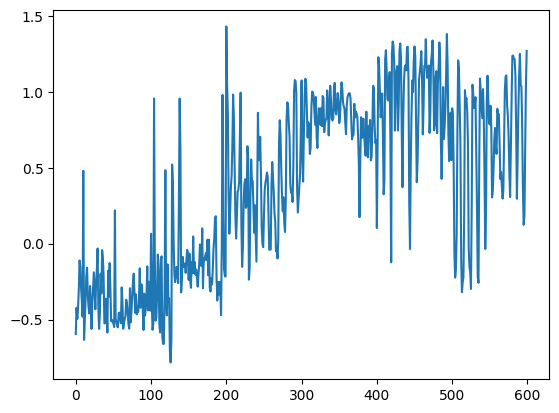

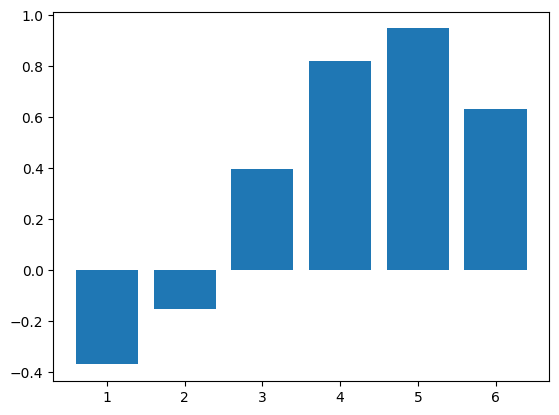

[2.9 2.6 2.3 2.  1.7 1.4]


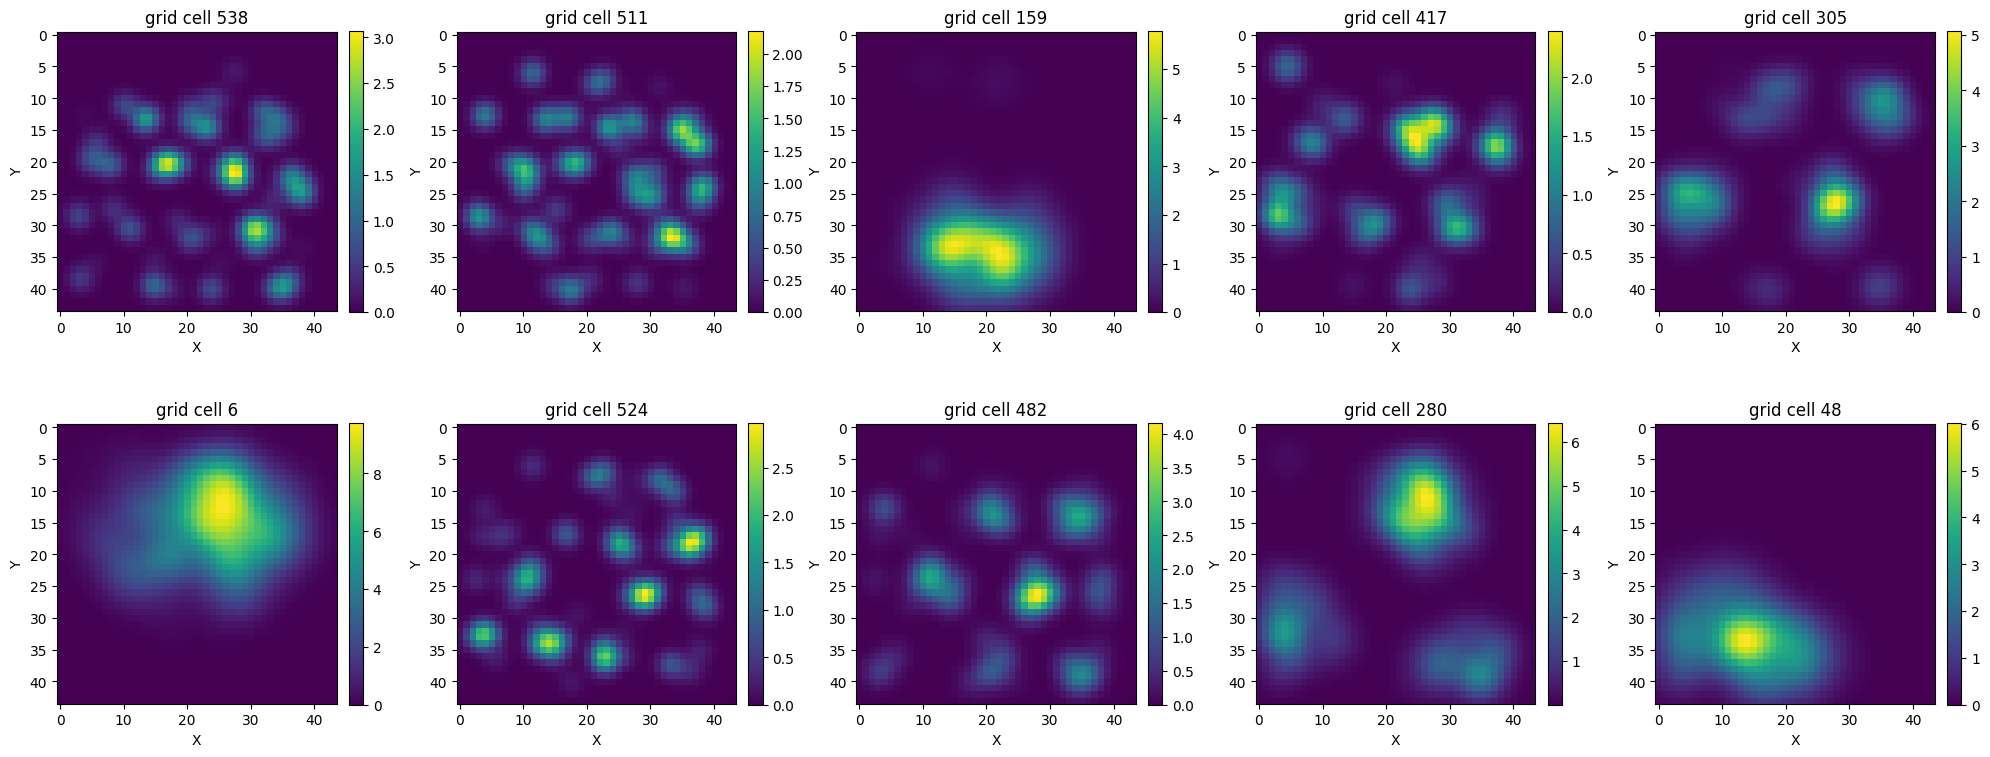

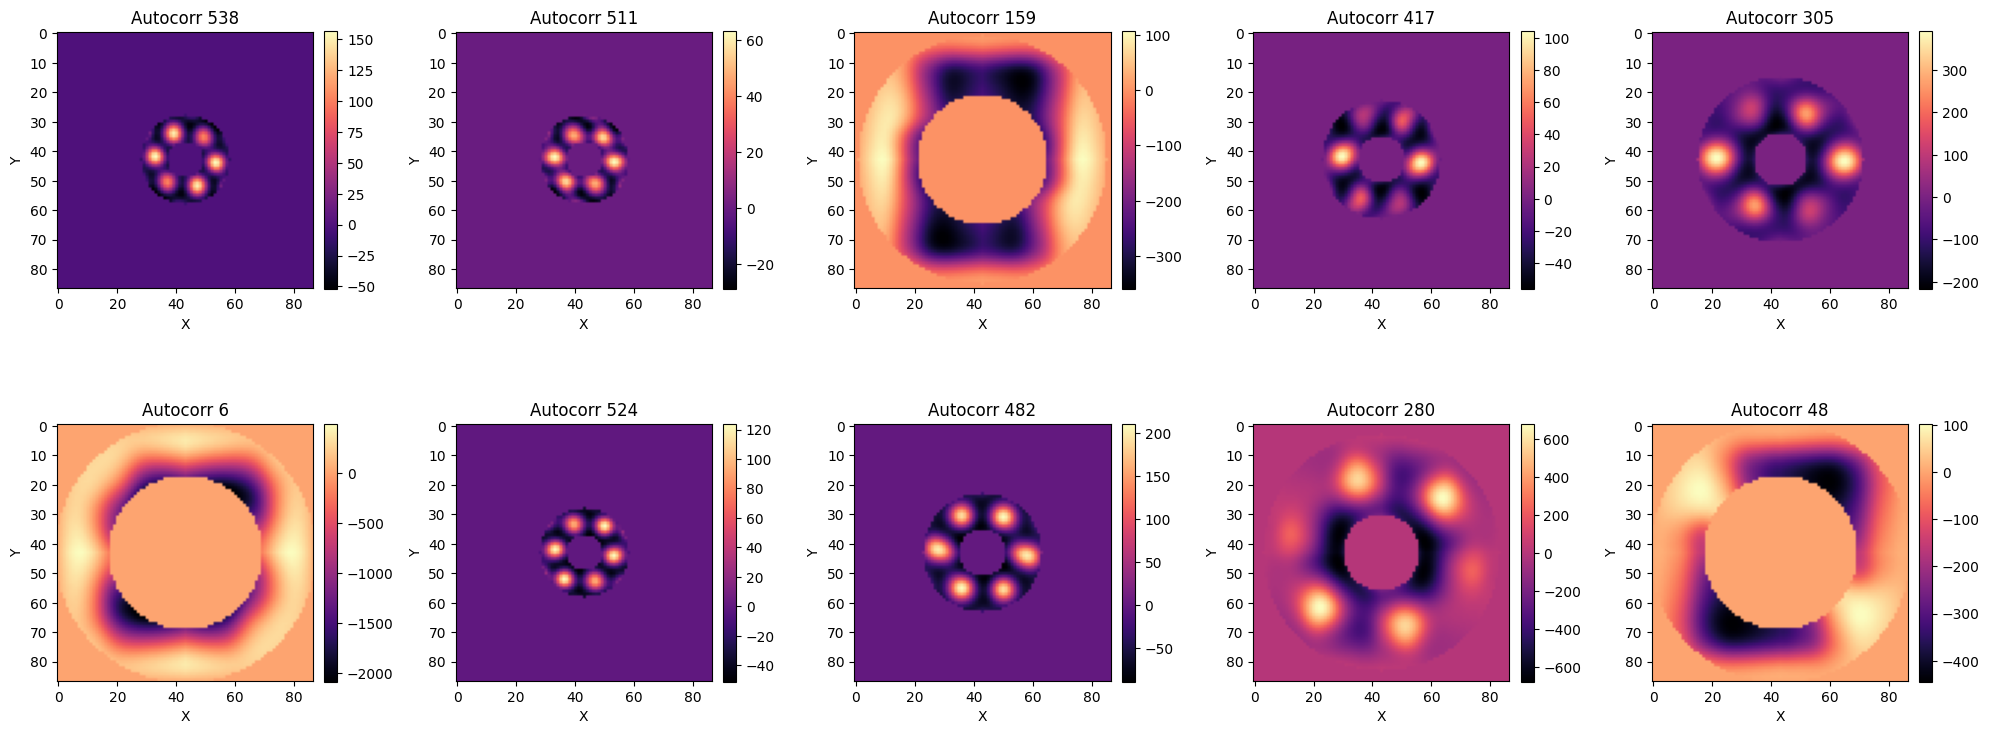

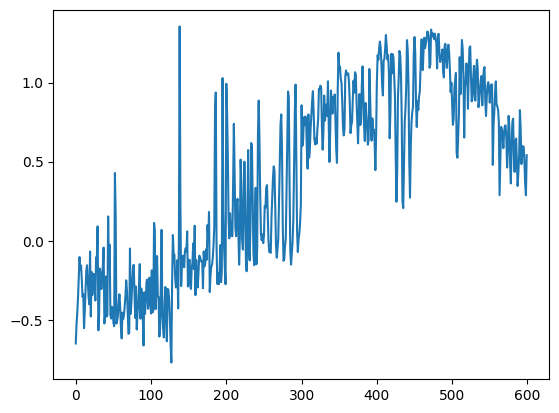

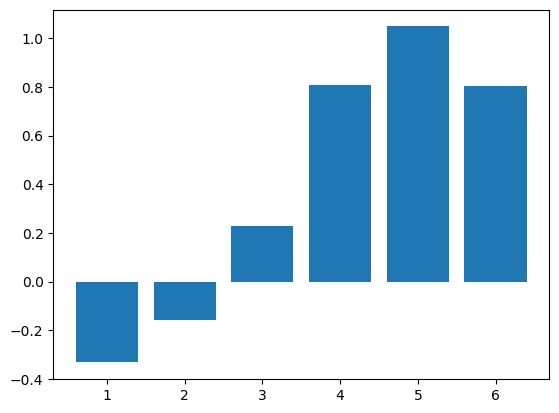

[2.9 2.6 2.3 2.  1.7 1.4]


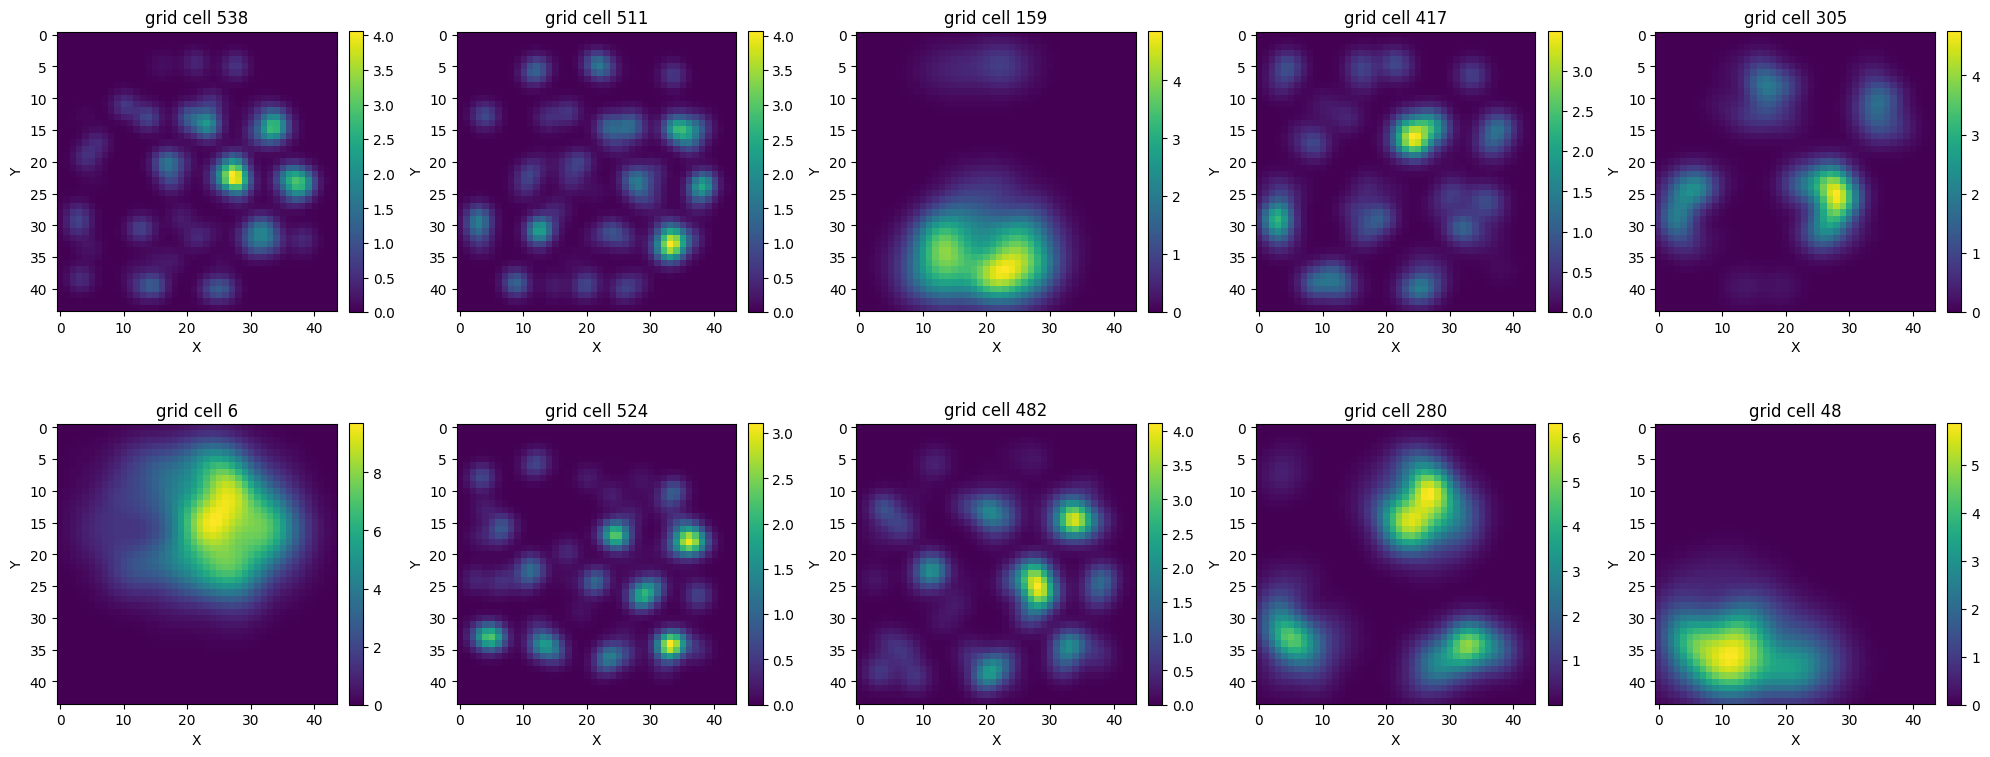

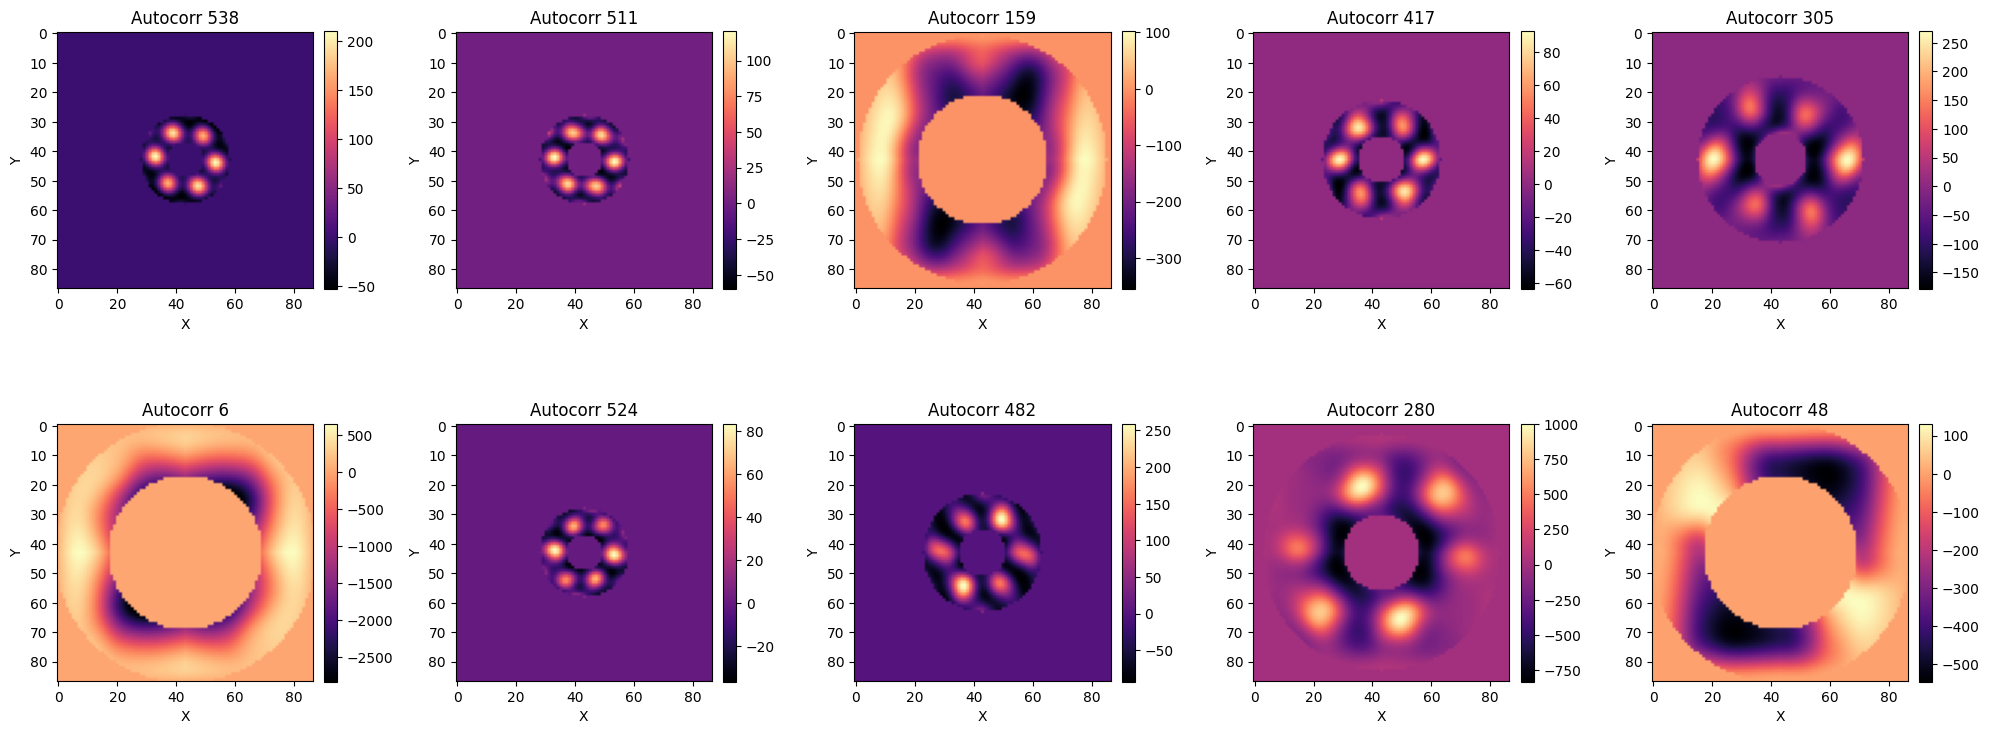

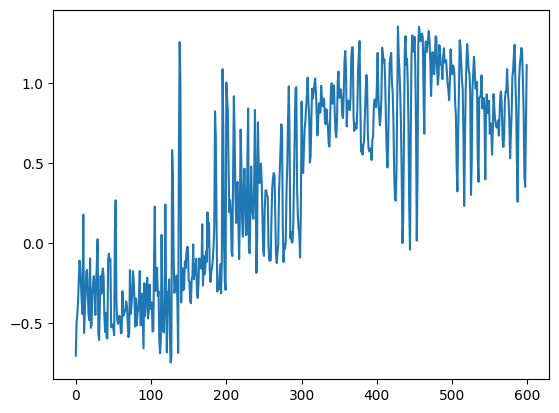

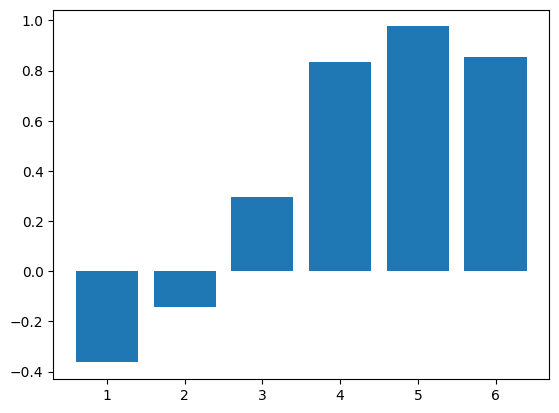

 10%|█         | 1/10 [03:28<31:14, 208.32s/it]

[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]


 20%|██        | 2/10 [06:43<26:42, 200.36s/it]

[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]


 30%|███       | 3/10 [09:58<23:06, 198.00s/it]

...

 80%|████████  | 8/10 [26:43<06:43, 201.83s/it]

[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]


 90%|█████████ | 9/10 [30:06<03:22, 202.18s/it]

[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]
[2.9 2.6 2.3 2.  1.7 1.4]


100%|██████████| 10/10 [33:29<00:00, 200.95s/it]


In [ ]:
# inspect and save grids with reduced samples
# uncomment plot lines to see outputs
# this creates a lot of plots

import numpy as np
import matplotlib.pyplot as plt
from helper_fcts import Gauss_kernel
from grid_cells import Gridness
from grid_cells import AutoCorr
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_gridness
from inspect_data_grids import plot_correlograms
from helper_fcts import load_dataset_and_GCs
from tqdm import tqdm

directory = 'datasets/oasis/'

configname = 'BaseModel_Noise0'

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)

all_stims = np.where(Stims[:,0] > 0)[0]

noise   = 0
broken  = 0
sig     = 1.5   # for Gauss HPC Kernel, 0.5 small, 1.5 big
# make range of sigmas, like different sized place fields
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1 

cleanup = 0.0   # clip small values to zero, flag itself is the threshold
N_plots = 10    ### even number please

samplesize = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]

N_it = 10
Gs   = np.zeros([N_GCs,len(samplesize),N_it])

for j in tqdm(range(N_it)): # do this 10 times 

    samples = {}
    n_stims = []

    for n in samplesize:
        samples[n] = {
            "sample_indices": np.random.choice(len(all_stims), size=n, replace=False)
            }
        n_stims = [n_stims, samples[n]["sample_indices"]]
        

    cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)

    for i in range(len(samplesize)):
        
        indices = samples[samplesize[i]]["sample_indices"]
        
        PVs_xy_tmp  = PVs_xy_data[indices,:]
        Stims_tmp   = Stims[indices,:]
        PVs_tmp     = PVs[indices,:]
        
        dataset_GCs = make_data_grids(N_GCs,res,Stims_tmp,PVs_xy_tmp,PVs_tmp, sig, sigr, cleanup)
        
        corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
        corr        = corr.data  # because this is a masked array
        G           = Gridness(corr, x, y, N_GCs)
        
        configname = 'BaseModel_Noise0'
        filename = f"datasets/oasis/{configname}_{samplesize[i]}samples_G_Corr_dataGCs.npz"
        np.savez(filename, G=G, correlograms=corr, dataset_GCs=dataset_GCs)
        
        if j == 0:
            plot_data_grids(dataset_GCs, N_plots, cells2show)
            #plot_correlograms(corr, N_plots, cells2show)
            #plot_gridness(G) 
            
        
        Gs[:,i,j] = G.reshape(-1) 


filename = f"datasets/oasis/{configname}_avg_samples_G.npy"
np.save(filename, Gs)


(6, 10)
(600, 10)
#####


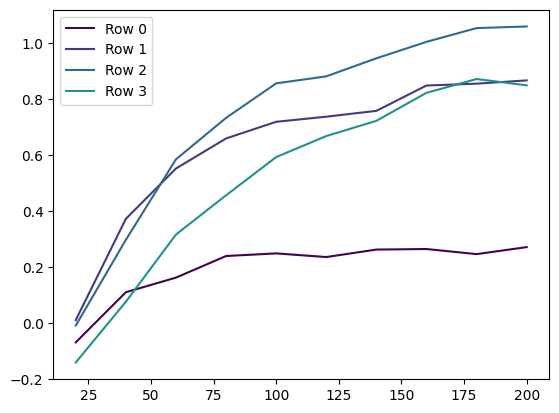

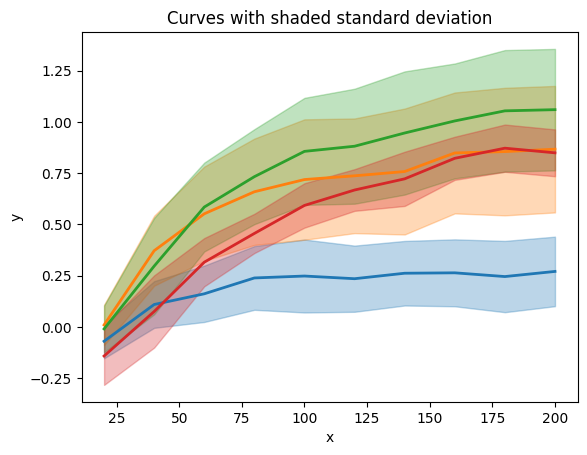

In [3]:
# load and plot gridness vs sample size 

import numpy as np
import matplotlib.pyplot as plt
from helper_fcts import calc_mean_gridness

configname = 'BaseModel_Noise0'

samplesize = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
samples = {}
results = {}

filename = f"datasets/oasis/{configname}_avg_samples_G.npy"
Gs = np.load(filename)

Gs_m   = np.zeros([N_mod,len(samplesize)])
Gs_std = np.zeros([N_mod,len(samplesize)])

for i in range(len(samplesize)):
    G_tmp = np.mean(Gs, axis=2)
    Gm, Gstd = calc_mean_gridness(G_tmp[:, i])
    Gs_m[:,i] = Gm
    Gs_std[:,i] = Gstd
    
print(Gs_m.shape)
print(G_tmp.shape)
print('#####')

Gs_m = Gs_m[2:]

plt.figure()
cmap = plt.cm.viridis
for i in range(Gs_m.shape[0]):
    plt.plot(samplesize, Gs_m[i,:], color=cmap(i/6), label=f'Row {i}')
plt.legend()
plt.show()

for i in range(Gs_m.shape[0]):
    line, = plt.plot(samplesize, Gs_m[i,:], linewidth=2)
    color = line.get_color()
    plt.fill_between(
        samplesize,
        Gs_m[i,:] - Gs_std[i,:],
        Gs_m[i,:] + Gs_std[i,:],
        color=color,
        alpha=0.3
    )
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curves with shaded standard deviation")
plt.show()

savename = f"datasets/oasis/{configname}_avg_samples_G_multiple_iterations.npy"
np.save(savename, Gs_m)


[2.9 2.6 2.3 2.  1.7 1.4]


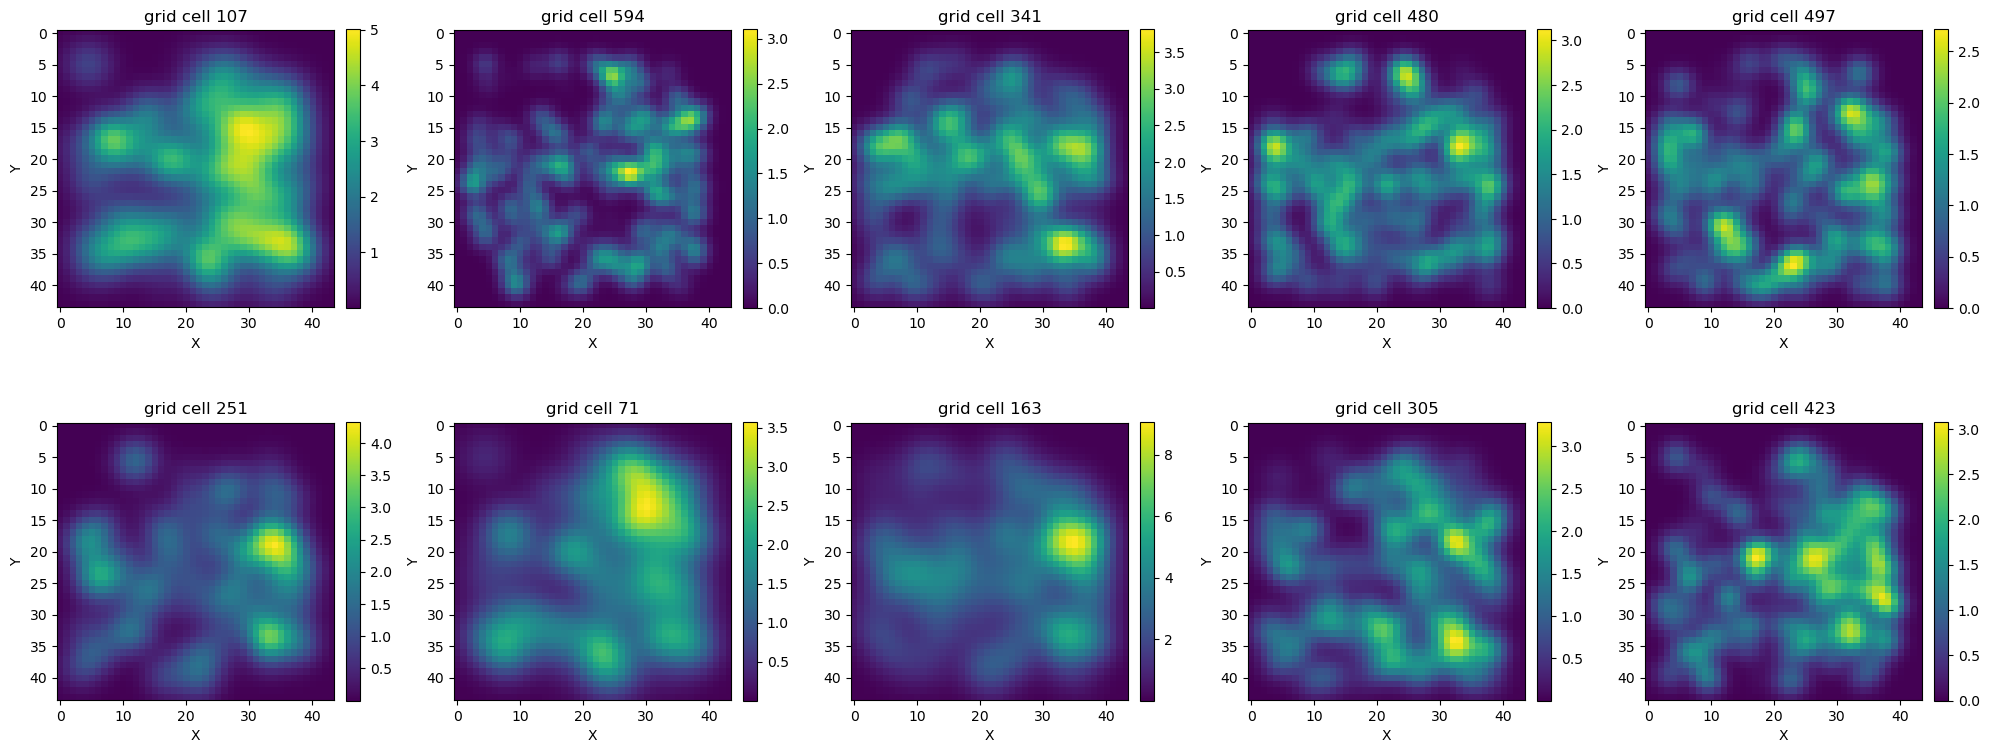

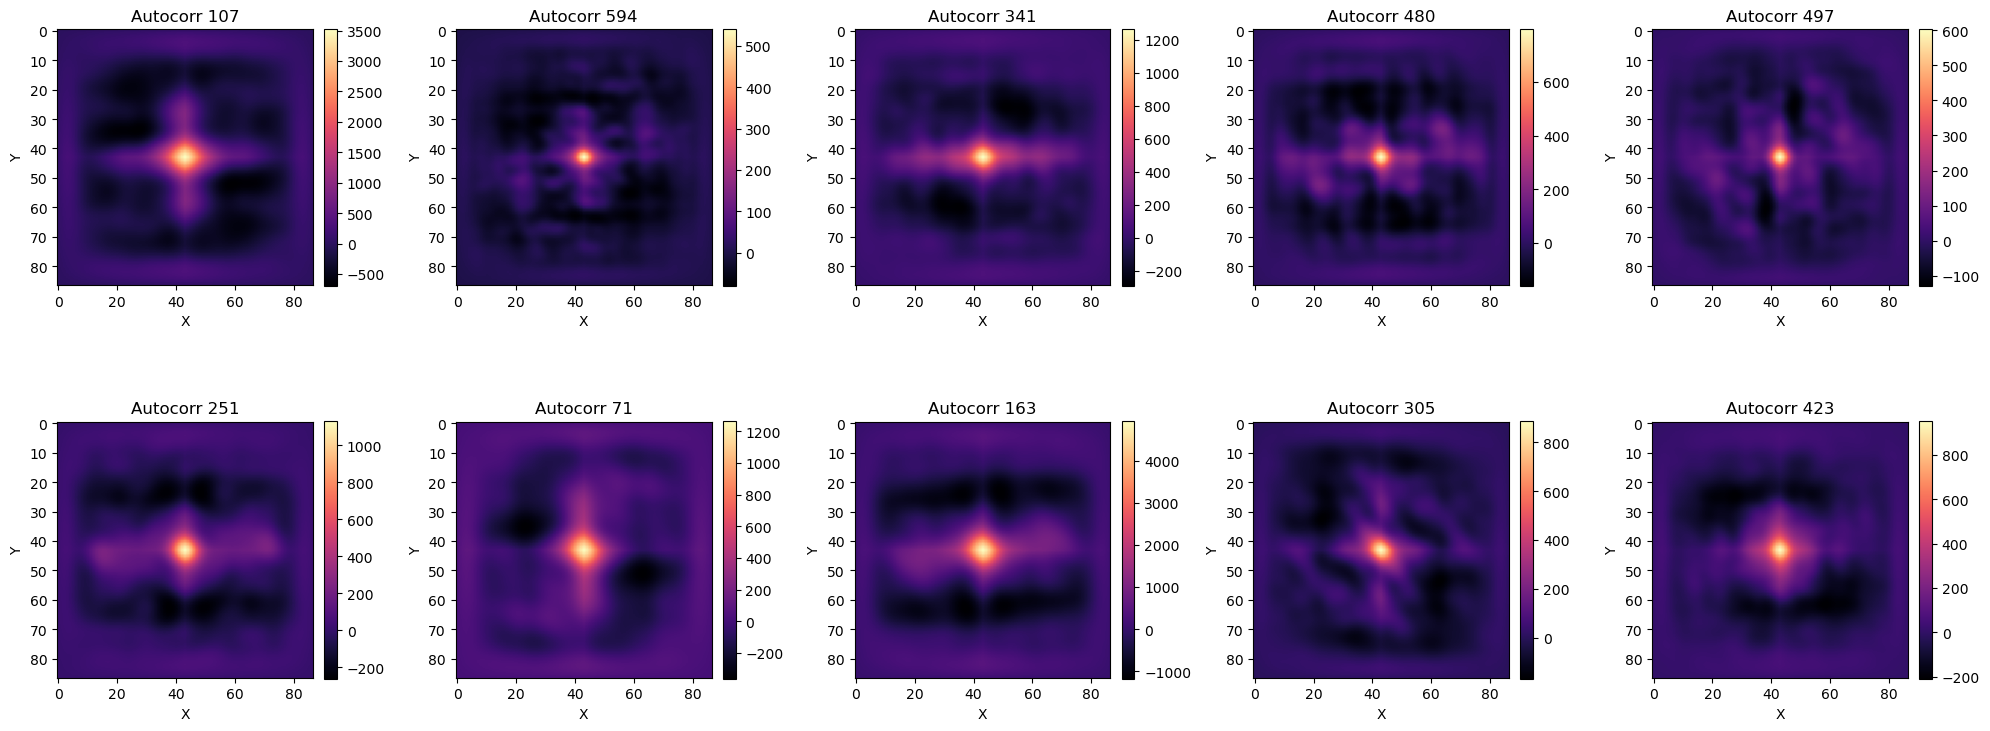

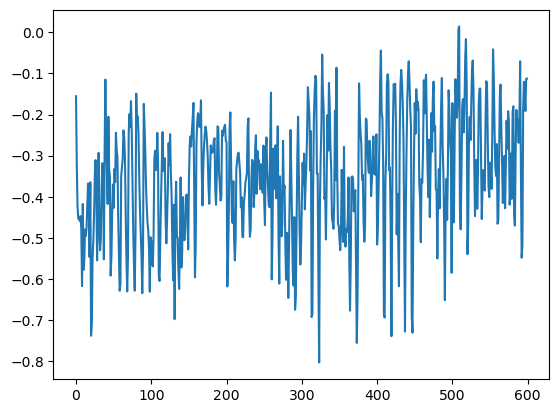

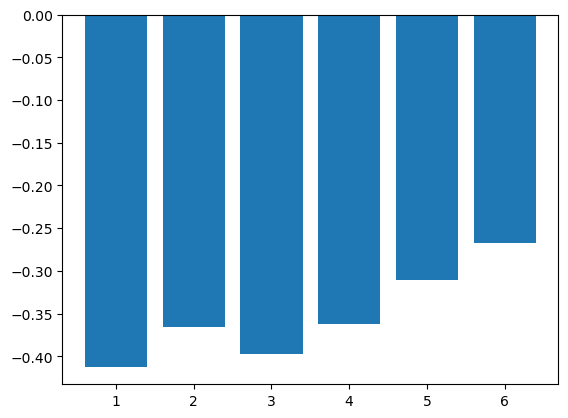

In [ ]:
# Quantifications and noise/shuffle check

# visualize dataset 1 with shuffled x,y. for vector errors during mapping see noise sims.

import numpy as np
import matplotlib.pyplot as plt
from helper_fcts import load_dataset_and_GCs
from grid_cells import Gridness
from grid_cells import AutoCorr
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_gridness
from inspect_data_grids import plot_correlograms

directory = 'datasets/oasis/'
configname = 'BaseModel_Noise0'

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)
dataset_GCs = np.zeros([res,res,N_GCs])

#####
shuffled_PVs_xy = np.random.permutation(PVs_xy_data) 
#####

sig = 1.5 # for Gauss HPC Kernel, 0.5 small, 1.5 big
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1 

cleanup = 0.0  # clip small values to zero, flag itself is the threshold
N_plots = 10 ### even number please
cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)

dataset_GCs = make_data_grids(N_GCs, res, Stims, shuffled_PVs_xy, PVs, sig, sigr, cleanup)
plot_data_grids(dataset_GCs, N_plots, cells2show)

corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
corr        = corr.data  # because this is a masked array
plot_correlograms(corr, N_plots, cells2show)
G           = Gridness(corr, x, y, N_GCs)
plot_gridness(G)


filename = f"datasets/oasis/{configname}_shuffled.npz"
np.savez(filename, G=G, correlograms=corr, xed=x, yed=y, dataset_GCs=dataset_GCs)
